# 5. Verbal Features (Annotated Corpus)

This notebook analyzes verbal features (VERB vs AUX) in the annotated corpus.

For each feature, we provide:
- Overall frequency distributions
- Per-text distributions

Additionally:
- Comparison between VERB and AUX
- Combined analysis of Person + Number + Mood

In [ ]:
import pickle
import sys
import os

# 1. the folder containing the parser, in this case Raha Musavi's parser
parser_path = r"\syntax_project\mp-corpus-parser"

# 2. Add the parser folder to Python's search path
if parser_path not in sys.path:
    sys.path.append(parser_path)

# 3. Imports the classes from the parser
from rm_mptf_parser import Sentence, Token

# 4. Path to the actual pickle file
pkl_file_path = r"\syntax_project\corpus\annotated_corpus.pkl"

# 5. Load the corpus
try:
    with open(pkl_file_path, 'rb') as f:
        annotated_corpus = pickle.load(f)
    print(f"Success! Loaded {len(annotated_corpus)} annotated sentences.")
except FileNotFoundError:
    print(f"Error: Could not find the file at {pkl_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Success! Loaded 18547 annotated sentences.


In [25]:
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
# --- Typo Correction Maps ---

# Normalize feature names
FEAT_NAME_MAP = {
    "verbform": "VerbForm",
    "verbform ": "VerbForm",
    "verbtype": "VerbType",
    "verbsubcat": "Subcat",
    "verbzype": "VerbType",
    "vrerbtype": "VerbType",
    "vertype": "VerbType",
    "verbtype ": "VerbType",
    "form": "VerbForm",
    "numver": "Number",
    "numeral": "Number",
}

# Normalize feature values
FEAT_VALUE_MAP = {
    # Number
    "sg": "Sing",
    "sing": "Sing",
    "sind": "Sing",
    "pl": "Plur",
    "plur": "Plur",
    
    # Mood
    "subj": "Sub",
    
    # Tense
    "prs": "Pres",
    
    # Subcat / VerbType
    "tran": "Tran",
    "intr": "Intr",
    "ntr": "Intr",
    "int": "Intr",
    "i": "Intr",
    
    # VerbForm
    "vnoun": "Vnoun",
    
    # Typo cleanup
    "yes?": "Yes",
}

In [27]:
def normalize_feat(name, value):
    # Clean strings
    name_clean = str(name).strip()
    value_clean = str(value).strip()
    
    # Normalize name
    name_lower = name_clean.lower()
    name_norm = FEAT_NAME_MAP.get(name_lower, name_clean)
    
    # Normalize value
    value_lower = value_clean.lower()
    value_norm = FEAT_VALUE_MAP.get(value_lower, value_clean)
    
    return name_norm, value_norm

In [28]:
def clean_filename(fname):
    # remove path + suffix
    base = os.path.basename(fname)
    base = base.replace("_mptf.conllu", "")
    return base

In [29]:
def get_feats_dict(token):
    feats = token.feats
    
    if not feats or feats == "_":
        return {}
    
    if isinstance(feats, dict):
        return feats
    
    feat_dict = {}
    for p in feats.split("|"):
        if "=" in p:
            k, v = p.split("=", 1)
            feat_dict[k] = v
    
    return feat_dict

In [30]:
def compute_feature_statistics(corpus):
    
    overall = defaultdict(lambda: defaultdict(Counter))
    per_text = defaultdict(lambda: defaultdict(lambda: defaultdict(Counter)))
    
    for sentence in corpus:
        file_name = clean_filename(sentence.file_name)
        
        for token in sentence.get_tokens():
            pos = str(token.upos).strip().upper()
            
            if pos not in ["VERB", "AUX"]:
                continue
            
            feats = get_feats_dict(token)
            
            for name, value in feats.items():
                
                # 🔥 APPLY NORMALIZATION HERE
                name, value = normalize_feat(name, value)
                
                overall[pos][name][value] += 1
                per_text[pos][file_name][name][value] += 1
    
    return overall, per_text

In [31]:
overall_stats, per_text_stats = compute_feature_statistics(annotated_corpus)

In [32]:
def print_overall_feature(overall, feature):
    print(f"\n=== {feature} (OVERALL) ===")
    
    for pos in ["VERB", "AUX"]:
        print(f"\n{pos}:")
        
        counter = overall[pos].get(feature, {})
        total = sum(counter.values())
        
        for value, count in Counter(counter).most_common():
            ratio = count / total if total else 0
            print(f"  {value}: {count} ({ratio:.3f})")

In [33]:
def print_per_text_feature(per_text, feature):
    print(f"\n=== {feature} (PER TEXT) ===")
    
    for pos in ["VERB", "AUX"]:
        print(f"\n--- {pos} ---")
        
        for file, feats in per_text[pos].items():
            if feature not in feats:
                continue
            
            print(f"\n{file}:")
            
            counter = feats[feature]
            total = sum(counter.values())
            
            for value, count in counter.most_common():
                ratio = count / total if total else 0
                print(f"  {value}: {count} ({ratio:.3f})")

In [34]:
def plot_feature_overall(overall, feature):
    
    for pos in ["VERB", "AUX"]:
        counter = overall[pos].get(feature, {})
        if not counter:
            continue
        
        total = sum(counter.values())
        
        labels = []
        values = []
        
        for v, c in Counter(counter).most_common():
            labels.append(v)
            values.append(c / total)
        
        plt.figure()
        plt.bar(labels, values)
        plt.title(f"{feature} ({pos})")
        plt.ylabel("Relative frequency")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [35]:
def plot_feature_per_text(per_text, feature, pos="VERB", top_n=5):
    
    rows = []
    
    for file, feats in per_text[pos].items():
        if feature not in feats:
            continue
        
        counter = feats[feature]
        total = sum(counter.values())
        
        for value, count in counter.items():
            rows.append((file, value, count / total))
    
    if not rows:
        return
    
    df = pd.DataFrame(rows, columns=["file", "value", "ratio"])
    
    pivot = df.pivot(index="file", columns="value", values="ratio").fillna(0)
    
    top_values = pivot.mean().sort_values(ascending=False).head(top_n).index
    pivot = pivot[top_values]
    
    pivot.plot(kind="bar", stacked=True, figsize=(12,6))
    plt.title(f"{feature} per text ({pos})")
    plt.ylabel("Relative frequency")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [36]:
def plot_verb_vs_aux(overall, feature):
    
    data = []
    
    for pos in ["VERB", "AUX"]:
        counter = overall[pos].get(feature, {})
        total = sum(counter.values())
        
        for value, count in counter.items():
            data.append({
                "pos": pos,
                "value": value,
                "ratio": count / total if total else 0
            })
    
    df = pd.DataFrame(data)
    pivot = df.pivot(index="value", columns="pos", values="ratio").fillna(0)
    
    pivot.plot(kind="bar")
    plt.title(f"{feature}: VERB vs AUX")
    plt.ylabel("Relative frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
def combined_person_number_mood(corpus):
    overall = defaultdict(Counter)
    
    for sentence in corpus:
        for token in sentence.get_tokens():
            pos = str(token.upos).strip().upper()
            
            if pos not in ["VERB", "AUX"]:
                continue
            
            feats = get_feats_dict(token)
            
            # normalize relevant features
            p = feats.get("Person")
            n = feats.get("Number")
            m = feats.get("Mood")
            
            if p:
                _, p = normalize_feat("Person", p)
            if n:
                _, n = normalize_feat("Number", n)
            if m:
                _, m = normalize_feat("Mood", m)
            
            if not any([p, n, m]):
                continue
            
            combo = f"P={p}|N={n}|M={m}"
            overall[pos][combo] += 1
    
    return overall

In [38]:
def plot_combined_top(combo_overall, pos="VERB", top_n=10):
    
    counter = combo_overall[pos]
    most_common = counter.most_common(top_n)
    
    labels = [k for k, _ in most_common]
    values = [v for _, v in most_common]
    
    total = sum(counter.values())
    ratios = [v / total for v in values]
    
    plt.figure(figsize=(10,5))
    plt.barh(labels, ratios)
    plt.title(f"Top combinations ({pos})")
    plt.xlabel("Relative frequency")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [ ]:
print_overall_feature(overall_stats, "Mood")



=== Mood (OVERALL) ===

VERB:
  Ind: 25942 (0.905)
  Nec: 1451 (0.051)
  Imp: 621 (0.022)
  Sub: 447 (0.016)
  Opt: 189 (0.007)
  Tran: 1 (0.000)

AUX:
  Ind: 4953 (0.919)
  Sub: 227 (0.042)
  Opt: 171 (0.032)
  Imp: 30 (0.006)
  Nec: 10 (0.002)


In [44]:
print_per_text_feature(per_text_stats, "Mood")



=== Mood (PER TEXT) ===

--- VERB ---

Col-DH-1:
  Ind: 15 (0.789)
  Sub: 4 (0.211)

Col-J2:
  Ind: 3 (0.600)
  Sub: 2 (0.400)

Col-K20-1:
  Ind: 1 (0.500)
  Sub: 1 (0.500)

Col-K43a-2:
  Ind: 3 (0.750)
  Sub: 1 (0.250)

Col-K5-1:
  Ind: 3 (1.000)

Col-K5-2:
  Ind: 6 (0.857)
  Opt: 1 (0.143)

Col-K7b-1:
  Ind: 2 (0.667)
  Sub: 1 (0.333)

Col-K7b-2:
  Ind: 6 (0.750)
  Sub: 2 (0.250)

Col-TD1-1:
  Ind: 7 (0.875)
  Sub: 1 (0.125)

Col-TD2-1:
  Ind: 1 (1.000)

Col-TD2-2:
  Ind: 2 (1.000)

DD-K35:
  Ind: 953 (0.957)
  Nec: 20 (0.020)
  Sub: 12 (0.012)
  Imp: 7 (0.007)
  Opt: 4 (0.004)

DD-TD4a:
  Ind: 924 (0.955)
  Nec: 19 (0.020)
  Sub: 12 (0.012)
  Imp: 9 (0.009)
  Opt: 4 (0.004)

Dk5-B:
  Ind: 275 (0.703)
  Nec: 110 (0.281)
  Opt: 5 (0.013)
  Sub: 1 (0.003)

DMX-K43a:
  Ind: 708 (0.893)
  Imp: 51 (0.064)
  Nec: 26 (0.033)
  Sub: 5 (0.006)
  Opt: 2 (0.003)
  Tran: 1 (0.001)

DMX-L19:
  Ind: 292 (0.957)
  Nec: 11 (0.036)
  Sub: 1 (0.003)
  Imp: 1 (0.003)

FrW10-K20:
  Ind: 36 (0.720)
  Im

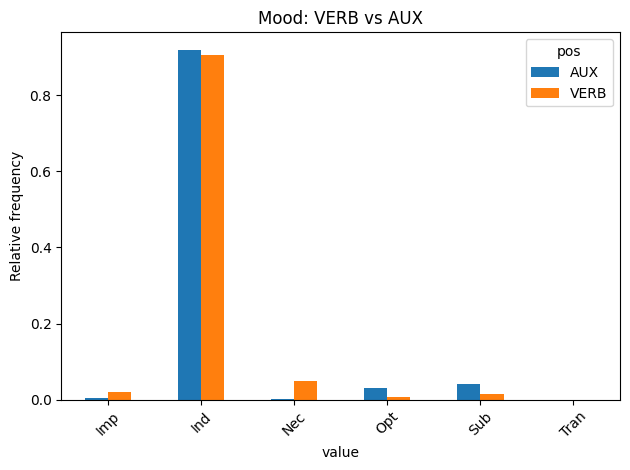

In [41]:
### 5.1 VERB vs AUX distinction
plot_verb_vs_aux(overall_stats, "Mood")


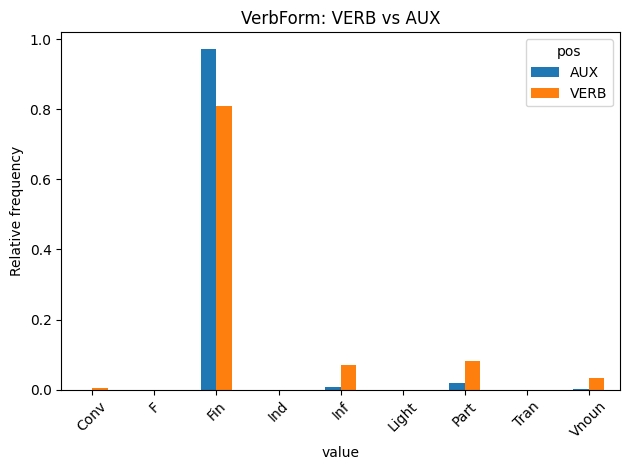

In [43]:
plot_verb_vs_aux(overall_stats, "VerbForm")

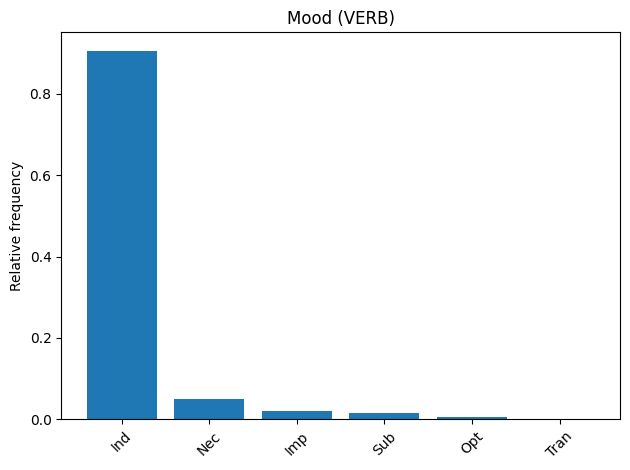

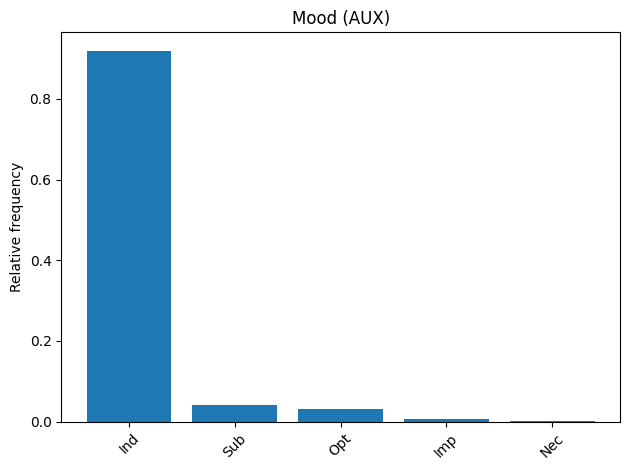

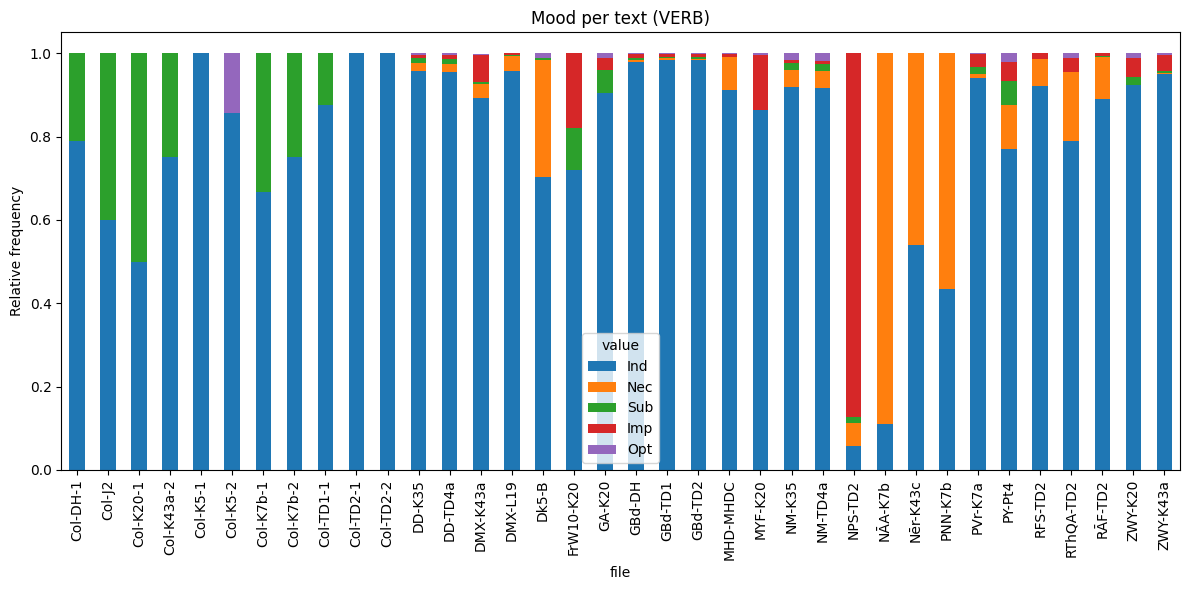

In [42]:
### 5.2 Mood
plot_feature_overall(overall_stats, "Mood")
plot_feature_per_text(per_text_stats, "Mood")


=== Number (OVERALL) ===

VERB:
  Sing: 22339 (0.826)
  Plur: 4690 (0.174)

AUX:
  Sing: 4007 (0.753)
  Plur: 1313 (0.247)


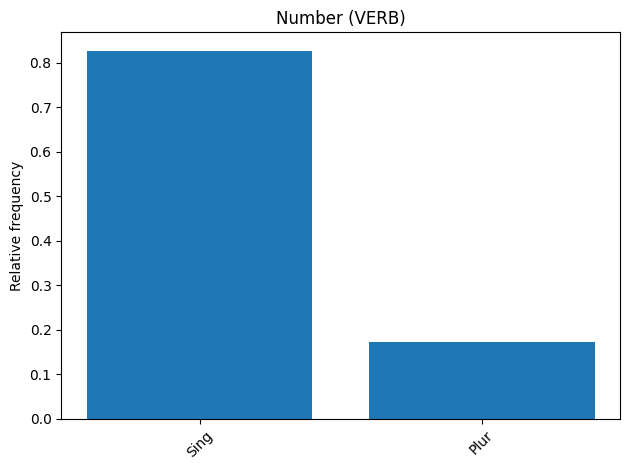

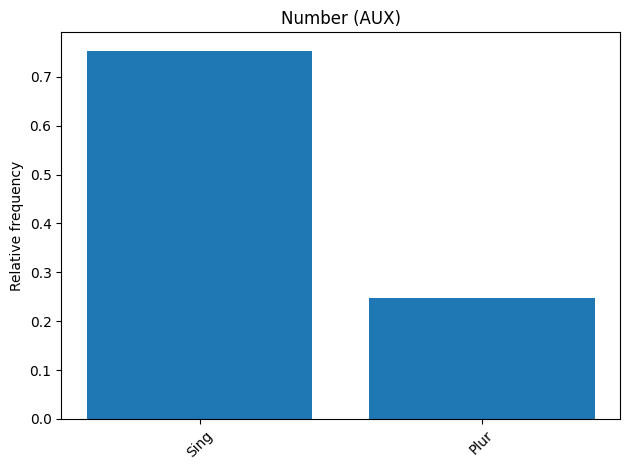

In [21]:
### 5.3 Number
print_overall_feature(overall_stats, "Number")
plot_feature_overall(overall_stats, "Number")

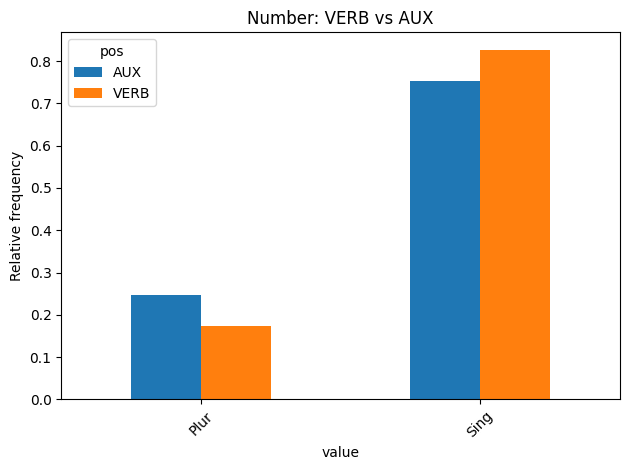

In [45]:
plot_verb_vs_aux(overall_stats, "Number")

In [23]:
print_per_text_feature(per_text_stats, "Number")


=== Number (PER TEXT) ===

--- VERB ---

Col-DH-1:
  Sing: 16 (0.842)
  Plur: 3 (0.158)

Col-J2:
  Sing: 5 (1.000)

Col-K20-1:
  Sing: 2 (1.000)

Col-K43a-2:
  Sing: 4 (1.000)

Col-K5-1:
  Sing: 2 (0.667)
  Plur: 1 (0.333)

Col-K5-2:
  Plur: 4 (0.571)
  Sing: 3 (0.429)

Col-K7b-1:
  Sing: 3 (1.000)

Col-K7b-2:
  Plur: 6 (0.750)
  Sing: 2 (0.250)

Col-TD1-1:
  Sing: 6 (0.750)
  Plur: 2 (0.250)

Col-TD2-1:
  Sing: 1 (1.000)

Col-TD2-2:
  Sing: 2 (1.000)

DD-K35:
  Sing: 794 (0.815)
  Plur: 180 (0.185)

DD-TD4a:
  Sing: 774 (0.816)
  Plur: 174 (0.184)

Dk5-B:
  Sing: 229 (0.854)
  Plur: 39 (0.146)

DMX-K43a:
  Sing: 656 (0.861)
  Plur: 106 (0.139)

DMX-L19:
  Sing: 251 (0.872)
  Plur: 37 (0.128)

FrW10-K20:
  Sing: 44 (0.880)
  Plur: 6 (0.120)

GA-K20:
  Sing: 127 (0.722)
  Plur: 49 (0.278)

GBd-DH:
  Sing: 2217 (0.846)
  Plur: 403 (0.154)

GBd-TD1:
  Sing: 2921 (0.836)
  Plur: 575 (0.164)

GBd-TD2:
  Sing: 2880 (0.830)
  Plur: 588 (0.170)

MHD-MHDC:
  Sing: 4106 (0.937)
  Plur: 278 (0.0


=== Person (OVERALL) ===

VERB:
  3: 23388 (0.865)
  1: 2595 (0.096)
  2: 1046 (0.039)

AUX:
  3: 4509 (0.848)
  1: 477 (0.090)
  2: 334 (0.063)


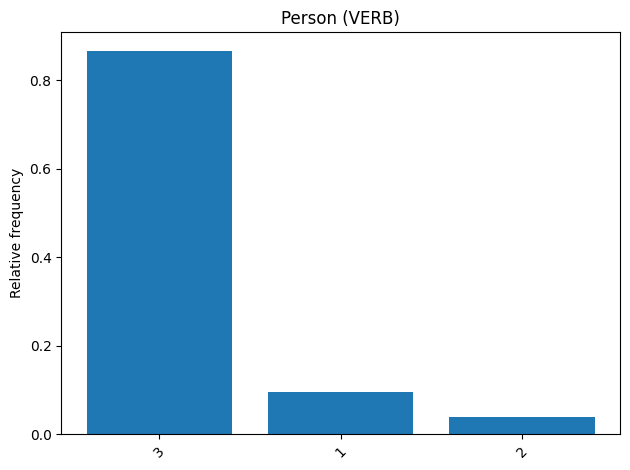

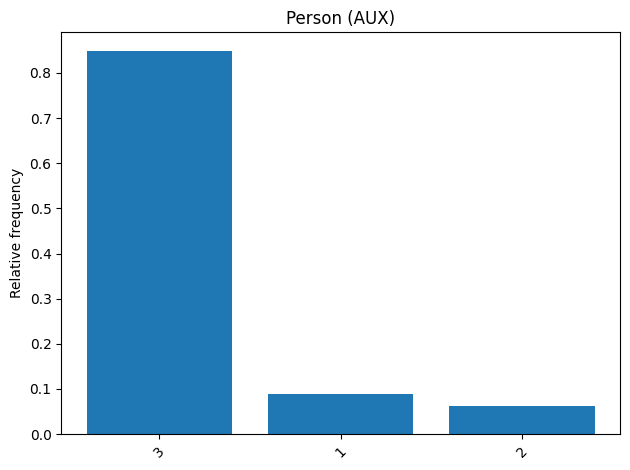

In [24]:
### 5.4 Person
print_overall_feature(overall_stats, "Person")
plot_feature_overall(overall_stats, "Person")

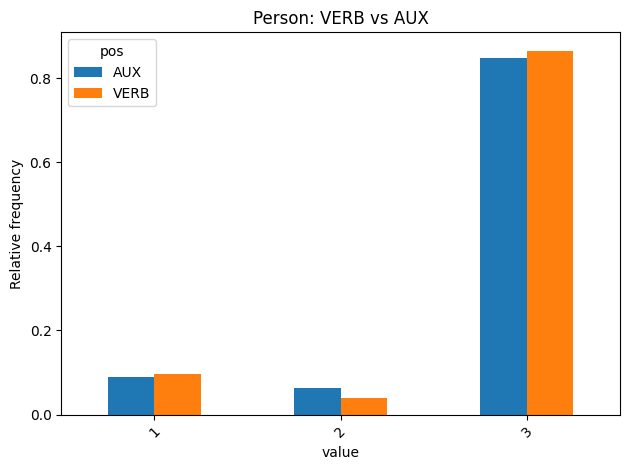

In [46]:
plot_verb_vs_aux(overall_stats, "Person")

In [25]:
print_per_text_feature(per_text_stats, "Person")



=== Person (PER TEXT) ===

--- VERB ---

Col-DH-1:
  3: 19 (1.000)

Col-J2:
  3: 5 (1.000)

Col-K20-1:
  3: 2 (1.000)

Col-K43a-2:
  3: 4 (1.000)

Col-K5-1:
  1: 2 (0.667)
  3: 1 (0.333)

Col-K5-2:
  3: 4 (0.571)
  2: 2 (0.286)
  1: 1 (0.143)

Col-K7b-1:
  3: 3 (1.000)

Col-K7b-2:
  3: 6 (0.750)
  1: 2 (0.250)

Col-TD1-1:
  3: 8 (1.000)

Col-TD2-1:
  3: 1 (1.000)

Col-TD2-2:
  3: 2 (1.000)

DD-K35:
  3: 931 (0.956)
  2: 28 (0.029)
  1: 15 (0.015)

DD-TD4a:
  3: 908 (0.958)
  2: 22 (0.023)
  1: 18 (0.019)

Dk5-B:
  3: 264 (0.985)
  1: 3 (0.011)
  2: 1 (0.004)

DMX-K43a:
  3: 697 (0.915)
  2: 52 (0.068)
  1: 13 (0.017)

DMX-L19:
  3: 286 (0.993)
  2: 2 (0.007)

FrW10-K20:
  3: 38 (0.760)
  2: 12 (0.240)

GA-K20:
  3: 159 (0.903)
  2: 11 (0.062)
  1: 6 (0.034)

GBd-DH:
  3: 2524 (0.963)
  1: 51 (0.019)
  2: 45 (0.017)

GBd-TD1:
  3: 3404 (0.974)
  1: 51 (0.015)
  2: 41 (0.012)

GBd-TD2:
  3: 3372 (0.972)
  1: 53 (0.015)
  2: 43 (0.012)

MHD-MHDC:
  3: 4170 (0.951)
  1: 165 (0.038)
  2: 4

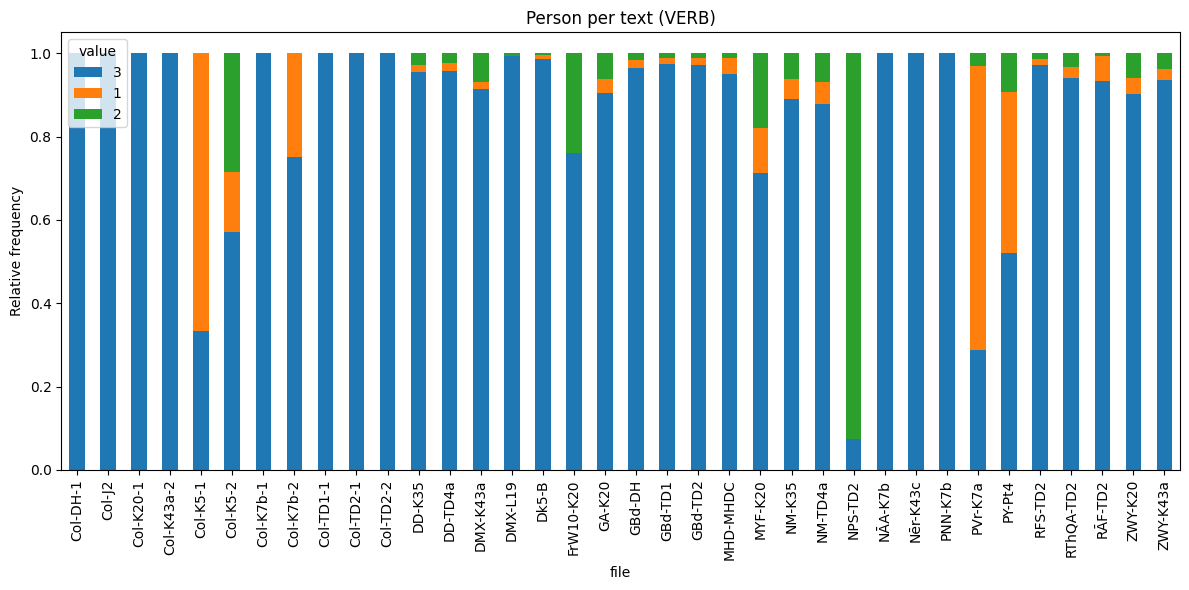

In [48]:
plot_feature_per_text(per_text_stats, "Person")


=== VerbForm (OVERALL) ===

VERB:
  Fin: 27010 (0.811)
  Part: 2677 (0.080)
  Inf: 2342 (0.070)
  Vnoun: 1116 (0.033)
  Conv: 167 (0.005)
  Ind: 2 (0.000)
  F: 2 (0.000)
  Light: 2 (0.000)
  Tran: 1 (0.000)

AUX:
  Fin: 5318 (0.972)
  Part: 108 (0.020)
  Inf: 41 (0.007)
  Vnoun: 6 (0.001)


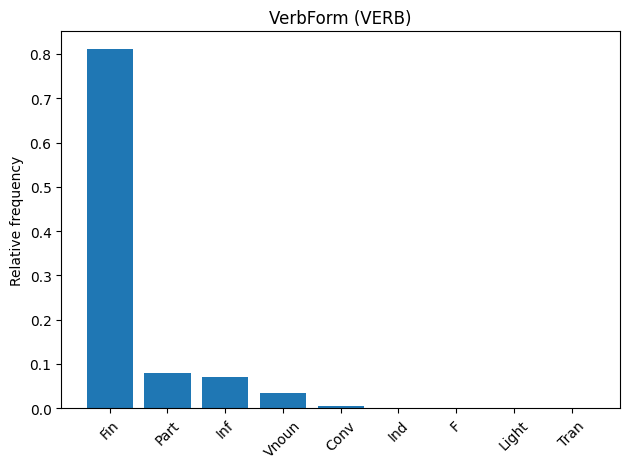

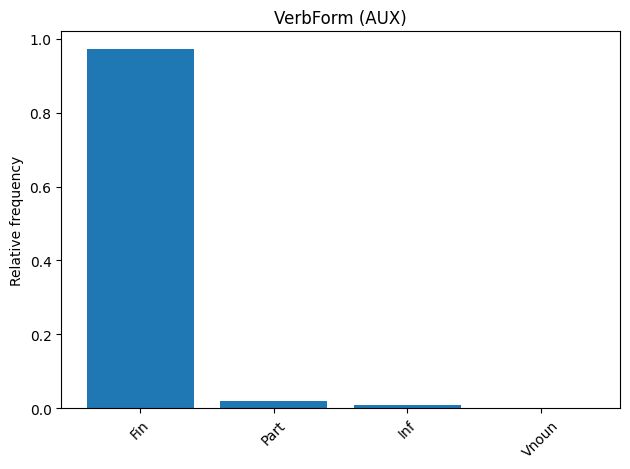

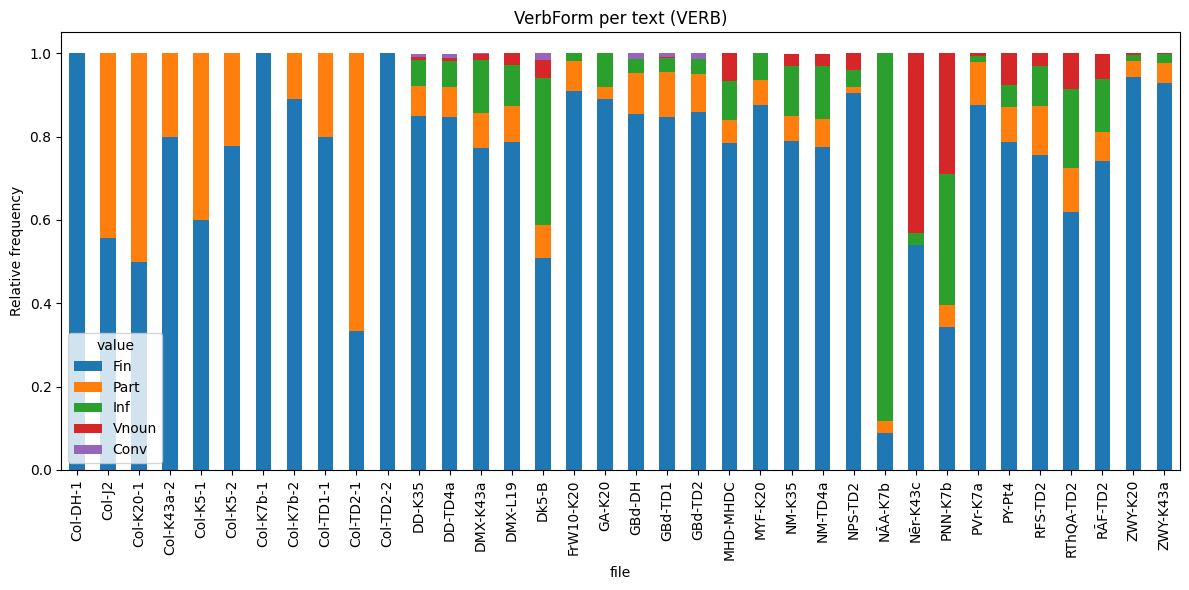

In [26]:
### 5.5 VerbForm
print_overall_feature(overall_stats, "VerbForm")
plot_feature_overall(overall_stats, "VerbForm")
plot_feature_per_text(per_text_stats, "VerbForm")

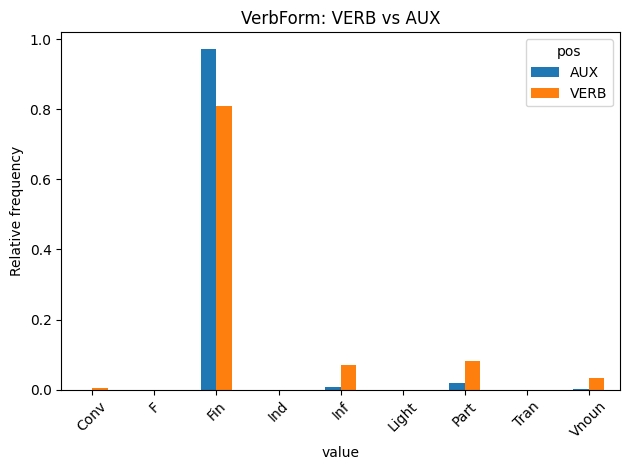

In [47]:
plot_verb_vs_aux(overall_stats, "VerbForm")

In [33]:
print_per_text_feature(per_text_stats, "VerbForm")



=== VerbForm (PER TEXT) ===

--- VERB ---

Col-DH-1:
  Fin: 19 (1.000)

Col-J2:
  Fin: 5 (0.556)
  Part: 4 (0.444)

Col-K20-1:
  Fin: 2 (0.500)
  Part: 2 (0.500)

Col-K43a-2:
  Fin: 4 (0.800)
  Part: 1 (0.200)

Col-K5-1:
  Fin: 3 (0.600)
  Part: 2 (0.400)

Col-K5-2:
  Fin: 7 (0.778)
  Part: 2 (0.222)

Col-K7b-1:
  Fin: 3 (1.000)

Col-K7b-2:
  Fin: 8 (0.889)
  Part: 1 (0.111)

Col-TD1-1:
  Fin: 8 (0.800)
  Part: 2 (0.200)

Col-TD2-1:
  Part: 2 (0.667)
  Fin: 1 (0.333)

Col-TD2-2:
  Fin: 2 (1.000)

DD-K35:
  Fin: 973 (0.850)
  Part: 81 (0.071)
  Inf: 72 (0.063)
  Conv: 10 (0.009)
  Vnoun: 8 (0.007)
  Ind: 1 (0.001)

DD-TD4a:
  Fin: 948 (0.847)
  Part: 80 (0.071)
  Inf: 71 (0.063)
  Conv: 12 (0.011)
  Vnoun: 7 (0.006)
  Ind: 1 (0.001)

Dk5-B:
  Fin: 267 (0.508)
  Inf: 186 (0.354)
  Part: 42 (0.080)
  Vnoun: 23 (0.044)
  Conv: 8 (0.015)

DMX-K43a:
  Fin: 762 (0.774)
  Inf: 125 (0.127)
  Part: 82 (0.083)
  Vnoun: 14 (0.014)
  Conv: 2 (0.002)

DMX-L19:
  Fin: 288 (0.787)
  Inf: 36 (0.098)
 


=== Tense (OVERALL) ===

VERB:
  Pres: 19317 (0.642)
  Past: 10764 (0.358)
  Opt: 2 (0.000)
  Plur: 2 (0.000)
  Fut: 2 (0.000)

AUX:
  Pres: 4775 (0.873)
  Past: 687 (0.126)
  Sing: 5 (0.001)
  Fut: 5 (0.001)


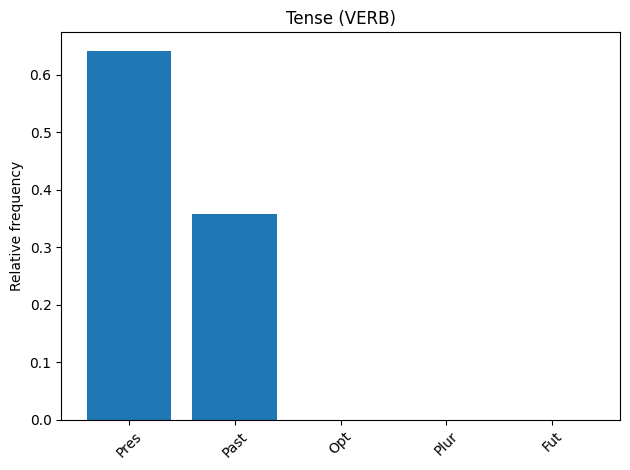

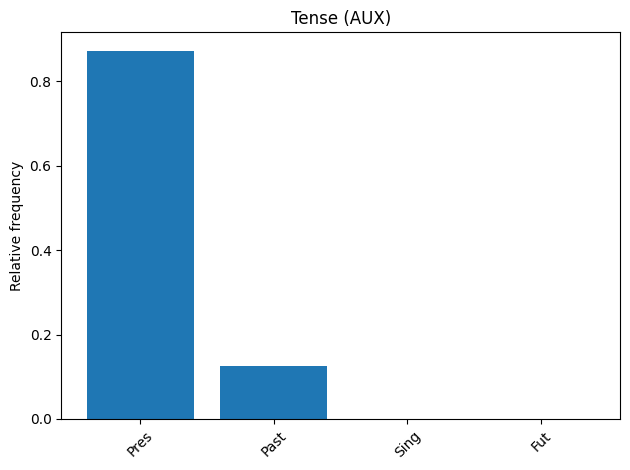

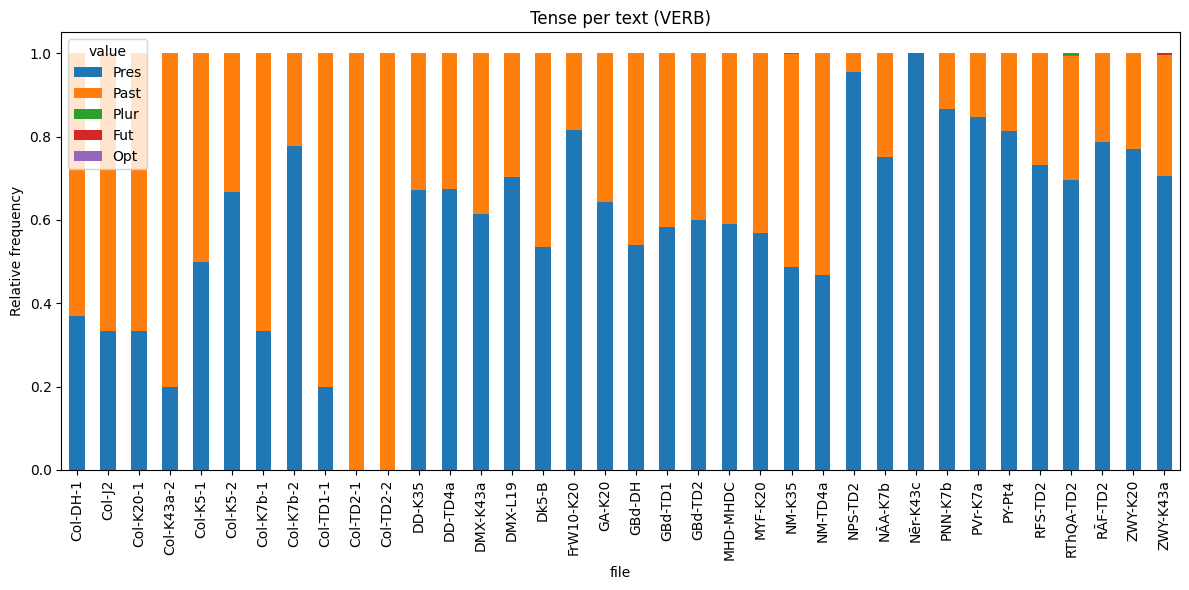

In [32]:
### 5.6 Tense
print_overall_feature(overall_stats, "Tense")
plot_feature_overall(overall_stats, "Tense")
plot_feature_per_text(per_text_stats, "Tense")

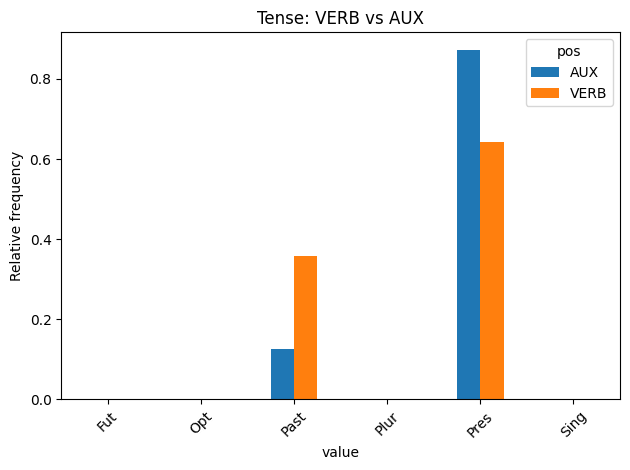

In [49]:
plot_verb_vs_aux(overall_stats, "Tense")

In [34]:
print_per_text_feature(per_text_stats, "Tense")



=== Tense (PER TEXT) ===

--- VERB ---

Col-DH-1:
  Past: 12 (0.632)
  Pres: 7 (0.368)

Col-J2:
  Past: 6 (0.667)
  Pres: 3 (0.333)

Col-K20-1:
  Past: 2 (0.667)
  Pres: 1 (0.333)

Col-K43a-2:
  Past: 4 (0.800)
  Pres: 1 (0.200)

Col-K5-1:
  Pres: 3 (0.500)
  Past: 3 (0.500)

Col-K5-2:
  Pres: 6 (0.667)
  Past: 3 (0.333)

Col-K7b-1:
  Past: 2 (0.667)
  Pres: 1 (0.333)

Col-K7b-2:
  Pres: 7 (0.778)
  Past: 2 (0.222)

Col-TD1-1:
  Past: 8 (0.800)
  Pres: 2 (0.200)

Col-TD2-1:
  Past: 3 (1.000)

Col-TD2-2:
  Past: 2 (1.000)

DD-K35:
  Pres: 715 (0.673)
  Past: 348 (0.327)

DD-TD4a:
  Pres: 700 (0.674)
  Past: 338 (0.326)

Dk5-B:
  Pres: 178 (0.535)
  Past: 155 (0.465)

DMX-K43a:
  Pres: 521 (0.613)
  Past: 329 (0.387)

DMX-L19:
  Pres: 229 (0.702)
  Past: 97 (0.298)

FrW10-K20:
  Pres: 44 (0.815)
  Past: 10 (0.185)

GA-K20:
  Pres: 117 (0.643)
  Past: 65 (0.357)

GBd-DH:
  Pres: 1608 (0.539)
  Past: 1374 (0.461)
  Opt: 1 (0.000)

GBd-TD1:
  Pres: 2345 (0.583)
  Past: 1674 (0.417)

GBd-TD

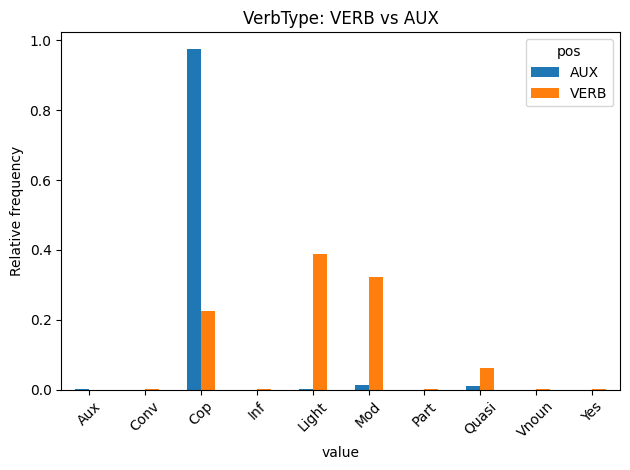

In [50]:
plot_verb_vs_aux(overall_stats, "VerbType")


=== VerbType (OVERALL) ===

VERB:
  Light: 1174 (0.388)
  Mod: 973 (0.322)
  Cop: 678 (0.224)
  Quasi: 188 (0.062)
  Part: 3 (0.001)
  Yes: 3 (0.001)
  Vnoun: 3 (0.001)
  Conv: 2 (0.001)
  Inf: 2 (0.001)

AUX:
  Cop: 5268 (0.974)
  Mod: 73 (0.014)
  Quasi: 61 (0.011)
  Light: 3 (0.001)
  Aux: 1 (0.000)


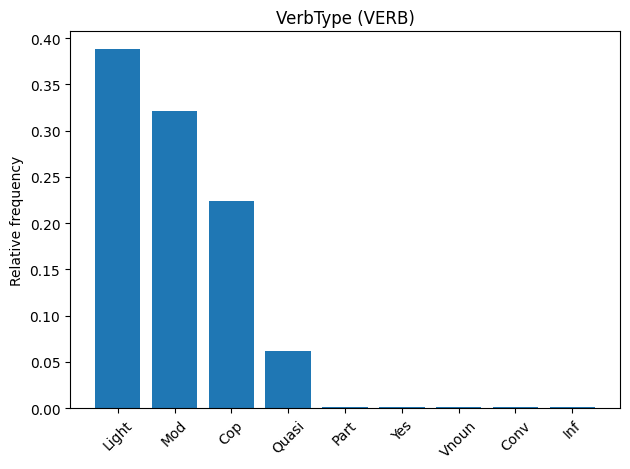

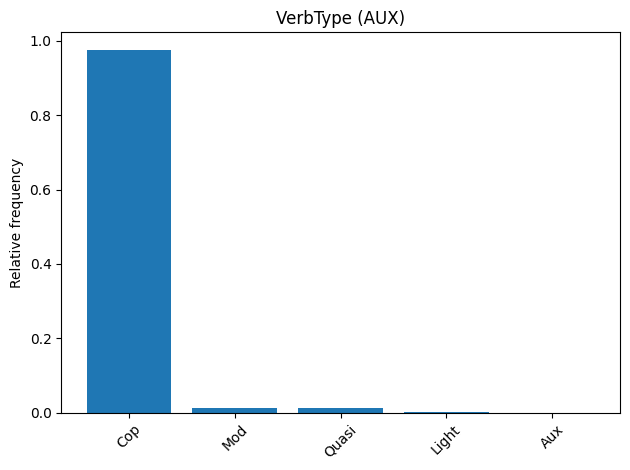

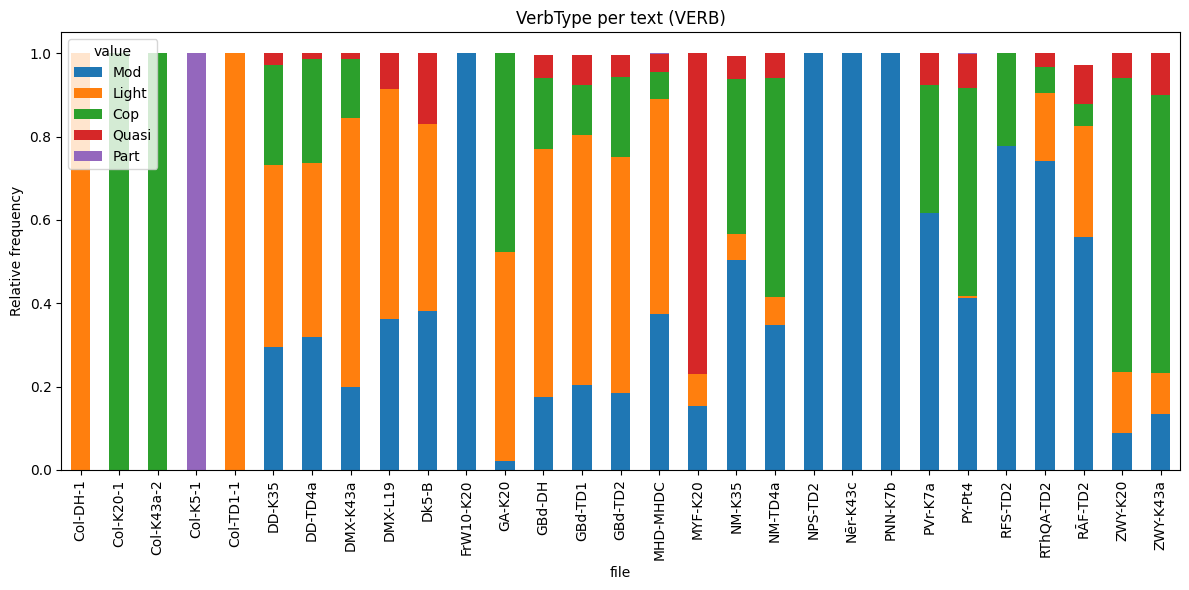

In [36]:
### 5.7 VerbType
print_overall_feature(overall_stats, "VerbType")
plot_feature_overall(overall_stats, "VerbType")
plot_feature_per_text(per_text_stats, "VerbType")

In [35]:
print_per_text_feature(per_text_stats, "VerbType")



=== VerbType (PER TEXT) ===

--- VERB ---

Col-DH-1:
  Light: 2 (1.000)

Col-K20-1:
  Cop: 1 (1.000)

Col-K43a-2:
  Cop: 1 (1.000)

Col-K5-1:
  Part: 1 (1.000)

Col-TD1-1:
  Light: 1 (1.000)

DD-K35:
  Light: 31 (0.437)
  Mod: 21 (0.296)
  Cop: 17 (0.239)
  Quasi: 2 (0.028)

DD-TD4a:
  Light: 30 (0.417)
  Mod: 23 (0.319)
  Cop: 18 (0.250)
  Quasi: 1 (0.014)

Dk5-B:
  Light: 34 (0.447)
  Mod: 29 (0.382)
  Quasi: 13 (0.171)

DMX-K43a:
  Light: 175 (0.646)
  Mod: 54 (0.199)
  Cop: 38 (0.140)
  Quasi: 4 (0.015)

DMX-L19:
  Light: 38 (0.551)
  Mod: 25 (0.362)
  Quasi: 6 (0.087)

FrW10-K20:
  Mod: 1 (1.000)

GA-K20:
  Light: 23 (0.500)
  Cop: 22 (0.478)
  Mod: 1 (0.022)

GBd-DH:
  Light: 141 (0.597)
  Mod: 41 (0.174)
  Cop: 40 (0.169)
  Quasi: 13 (0.055)
  Yes: 1 (0.004)

GBd-TD1:
  Light: 187 (0.601)
  Mod: 63 (0.203)
  Cop: 37 (0.119)
  Quasi: 23 (0.074)
  Yes: 1 (0.003)

GBd-TD2:
  Light: 176 (0.568)
  Cop: 59 (0.190)
  Mod: 57 (0.184)
  Quasi: 17 (0.055)
  Yes: 1 (0.003)

MHD-MHDC:
  Li

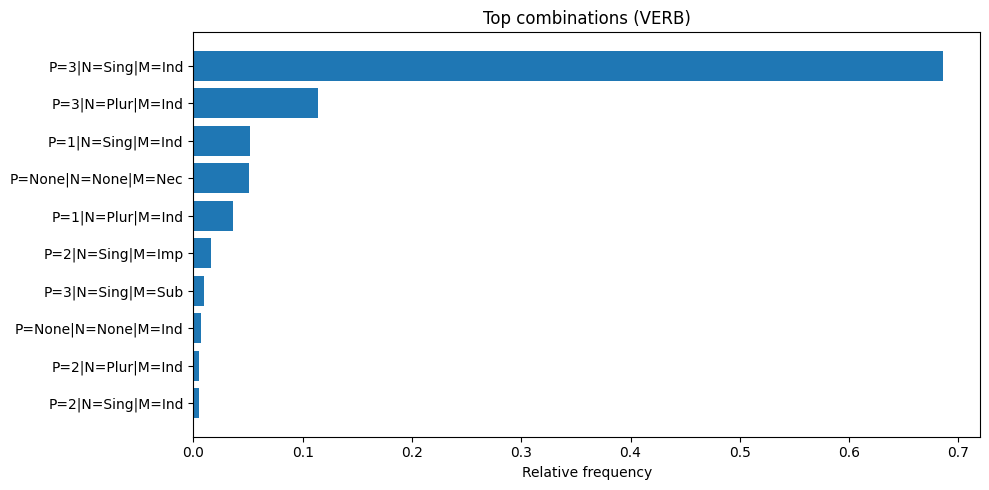

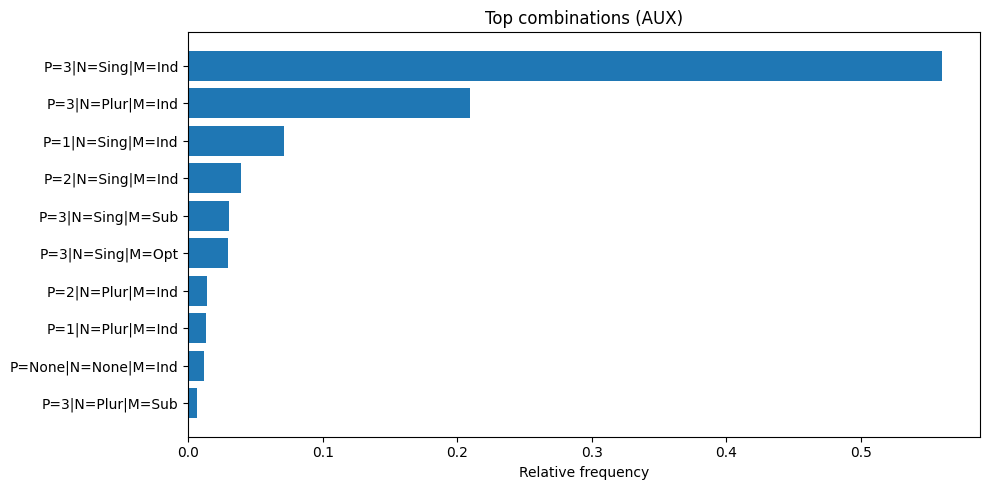

In [31]:
### 5.8 Person + Number + Mood
combo_overall = combined_person_number_mood(annotated_corpus)

plot_combined_top(combo_overall, "VERB")
plot_combined_top(combo_overall, "AUX")

In [52]:

import matplotlib.pyplot as plt
from collections import defaultdict, Counter


def combined_person_number_mood_per_text(corpus):
    results = {
        "VERB": defaultdict(Counter),
        "AUX": defaultdict(Counter)
    }

    for sent in corpus:
        text = sent.file_name

        for tok in sent.get_tokens():
            pos = tok.upos
            if pos not in ["VERB", "AUX"]:
                continue

            # ✅ FIX HERE
            feats = tok.feats or {}

            person = feats.get("Person", "None")
            number = feats.get("Number", "None")
            mood = feats.get("Mood", "None")

            combo = f"{person}-{number}-{mood}"

            results[pos][text][combo] += 1

    return results
def plot_combined_per_text(results, pos, top_n=5):
    for text, counter in results[pos].items():

        total = sum(counter.values())
        most_common = counter.most_common(top_n)

        labels = [k for k, v in most_common]
        values = [v / total for k, v in most_common]

        plt.figure()
        plt.bar(labels, values)
        plt.title(f"{pos} – {text} (Top {top_n} Person+Number+Mood)")
        plt.xticks(rotation=45)
        plt.ylabel("Relative Frequency")
        plt.tight_layout()
        plt.show()

In [57]:

### 5.8 Person + Number + Mood (PER TEXT)

combo_per_text = combined_person_number_mood_per_text(annotated_corpus)



In [54]:
import pandas as pd

def combined_per_text_dataframe(results, pos):
    rows = []

    for text, counter in results[pos].items():
        total = sum(counter.values())

        for combo, count in counter.items():
            ratio = count / total if total > 0 else 0

            rows.append({
                "Text": text,
                "Combination": combo,
                "Count": count,
                "Ratio": ratio
            })

    df = pd.DataFrame(rows)

    return df.sort_values(["Text", "Count"], ascending=[True, False])
combo_per_text = combined_person_number_mood_per_text(annotated_corpus)
df_verb = combined_per_text_dataframe(combo_per_text, "VERB")
df_aux = combined_per_text_dataframe(combo_per_text, "AUX")

df_verb.head(200)

,Text,Combination,Count,Ratio
0,Col-DH-1,3-Sing-Ind,12,0.631579
1,Col-DH-1,3-Sing-Sub,4,0.210526
2,Col-DH-1,3-Plur-Ind,3,0.157895
3,Col-J2,None-None-None,4,0.444444
4,Col-J2,3-Sing-Ind,3,0.333333
...,...,...,...,...
195,MHD-MHDC,1-Sing-Sub,1,0.000178
196,MHD-MHDC,2-Sing-Sub,1,0.000178
198,MYF-K20,3-Sing-Ind,235,0.567633
201,MYF-K20,None-None-None,50,0.120773


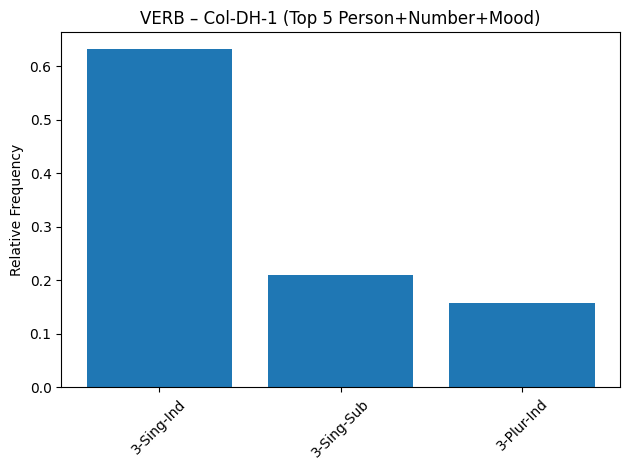

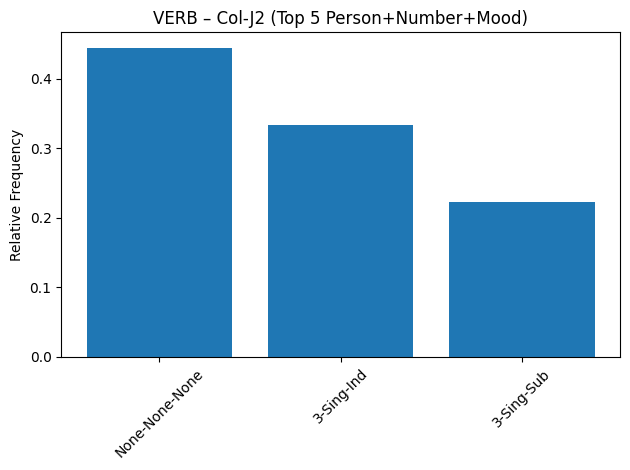

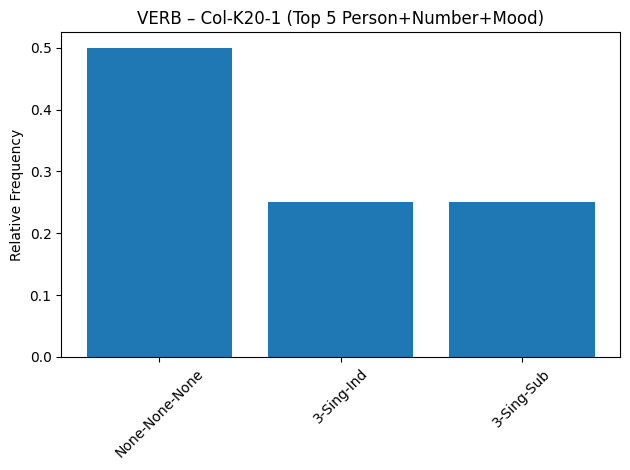

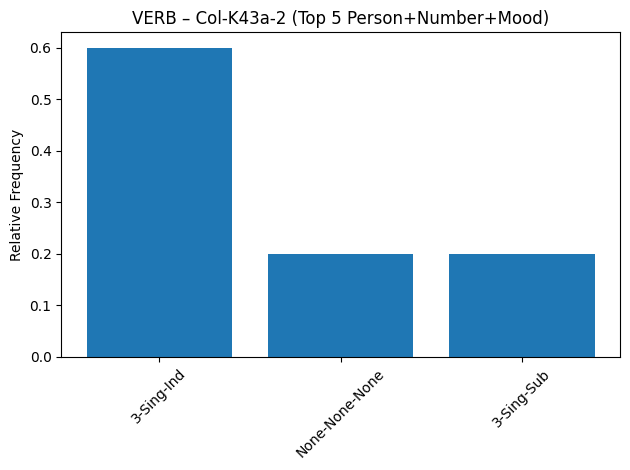

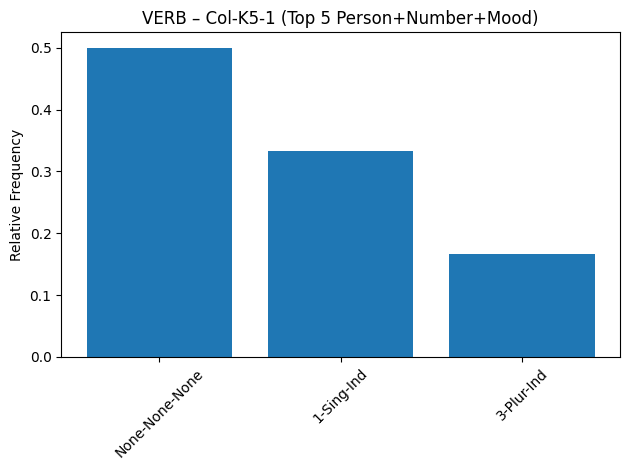

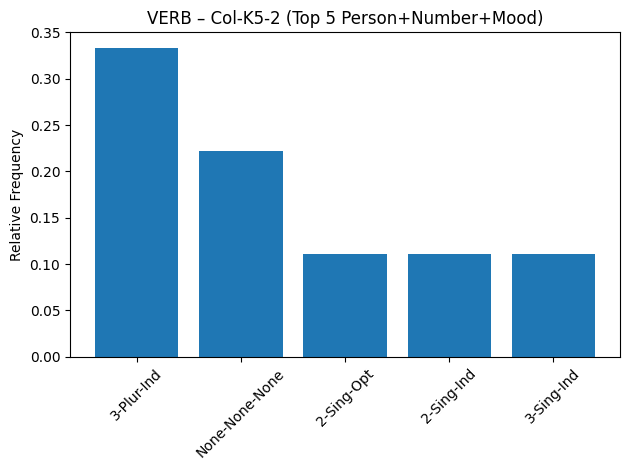

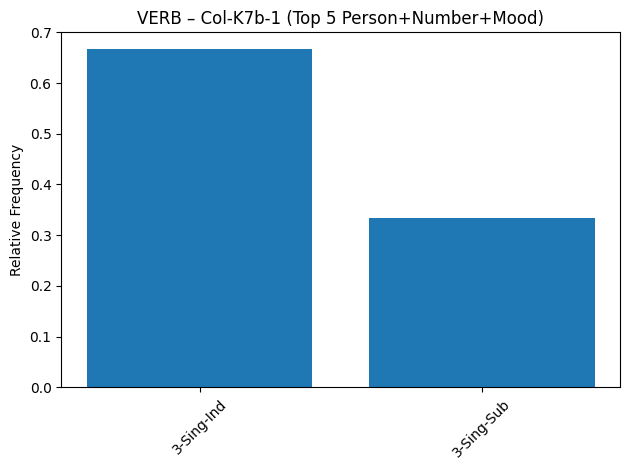

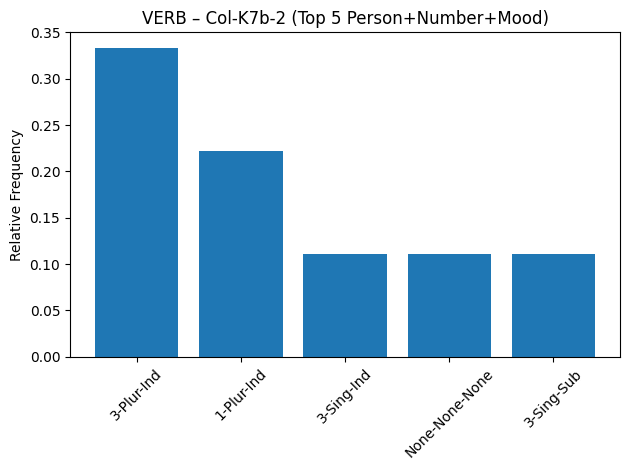

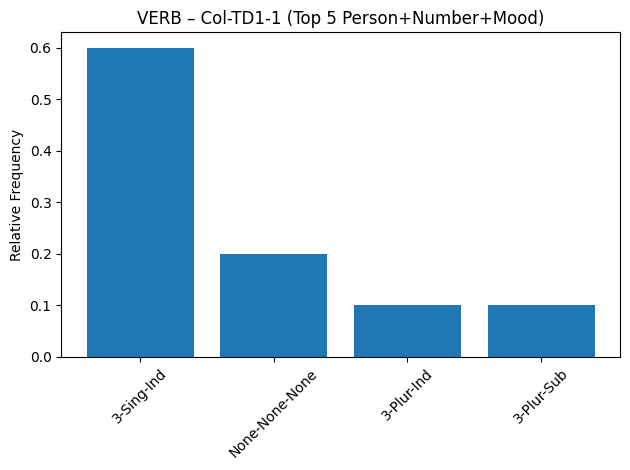

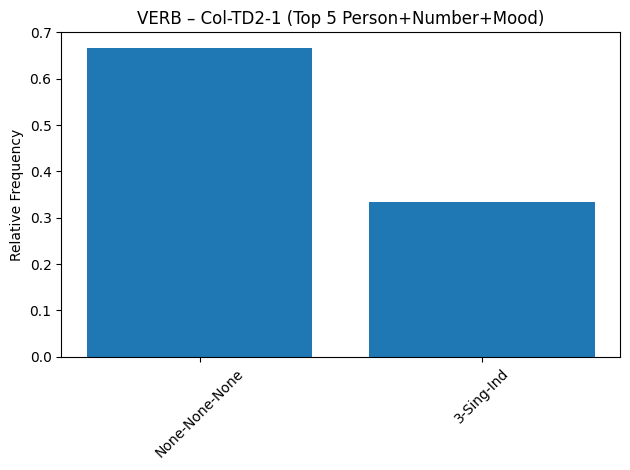

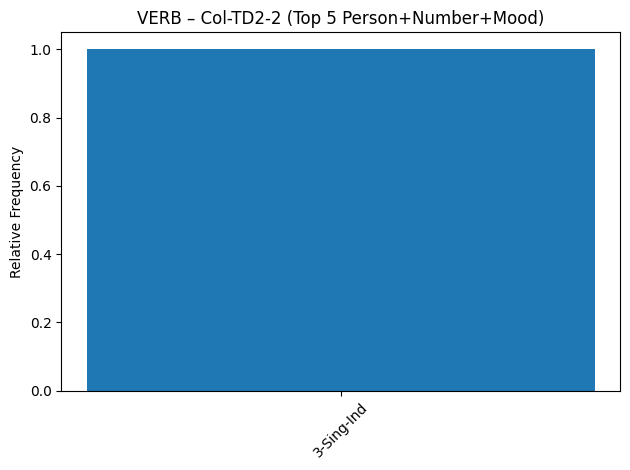

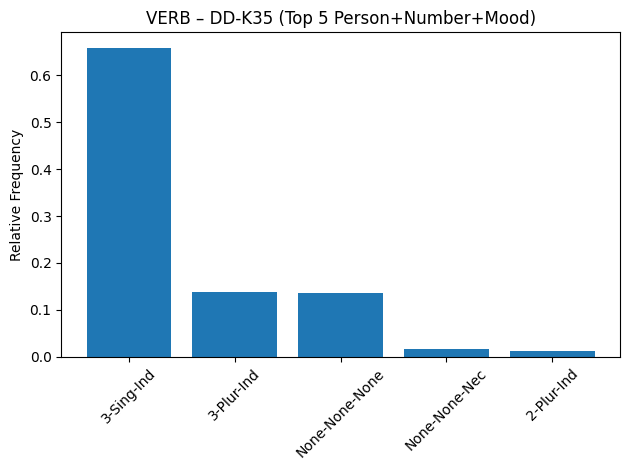

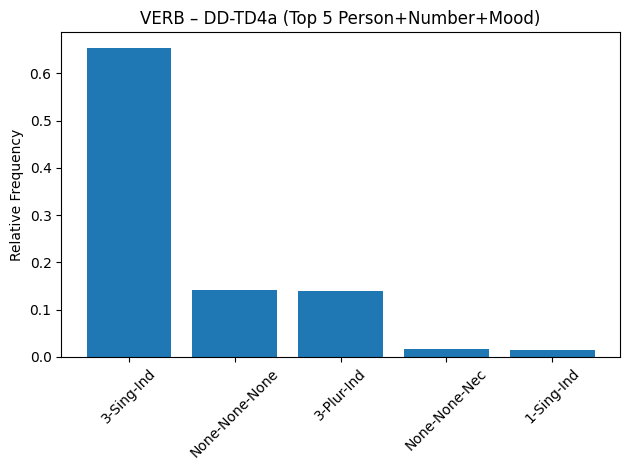

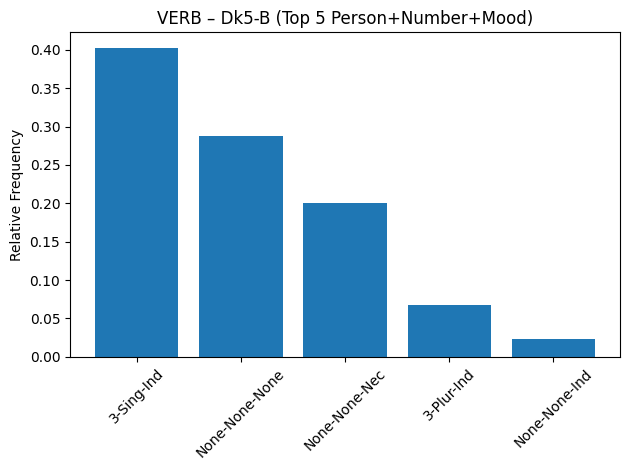

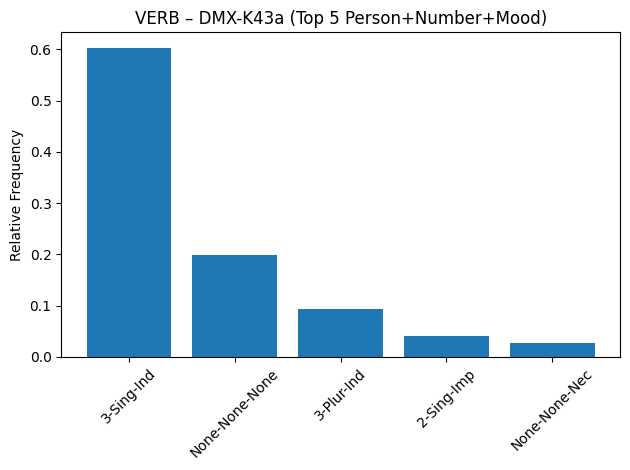

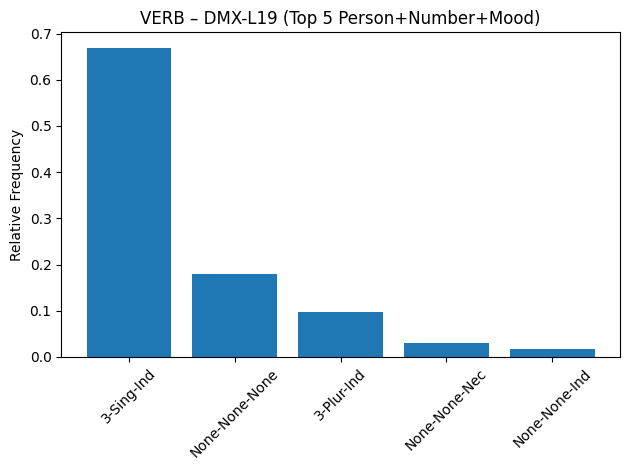

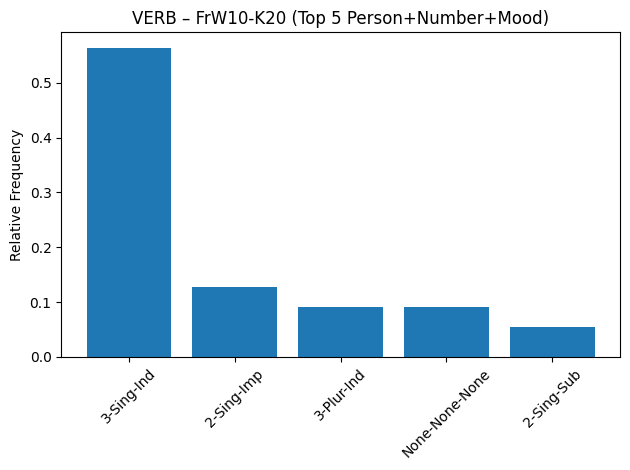

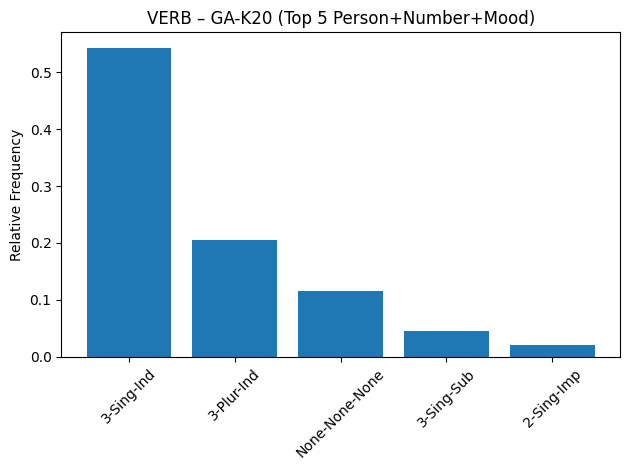

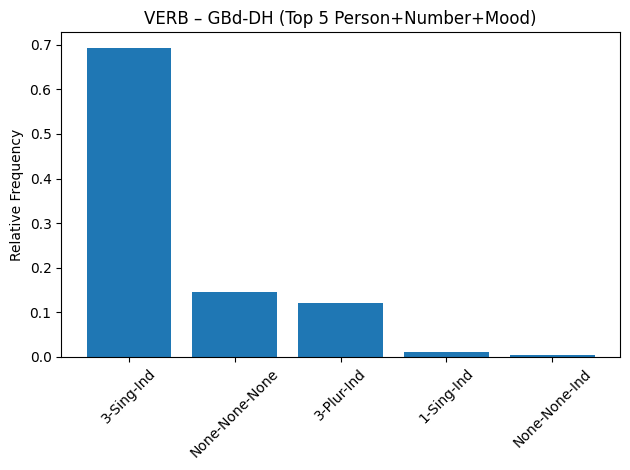

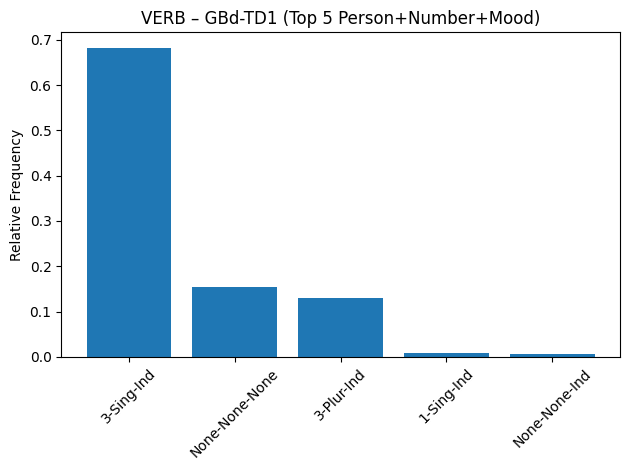

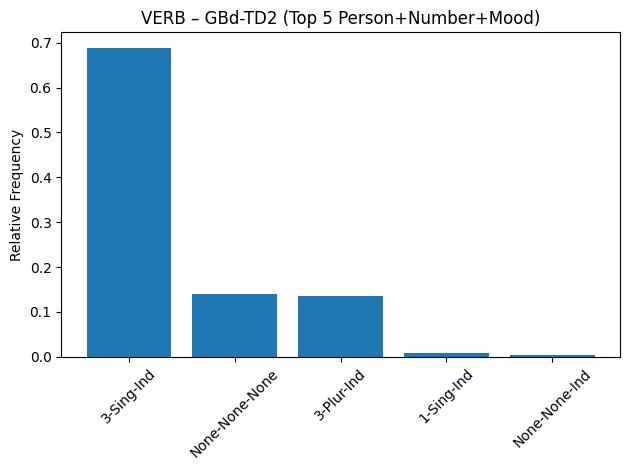

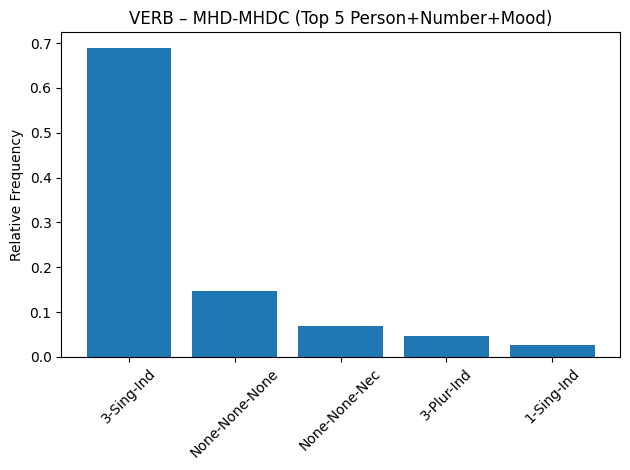

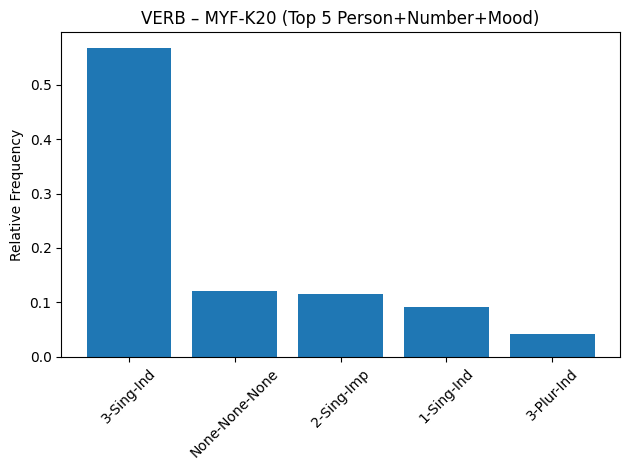

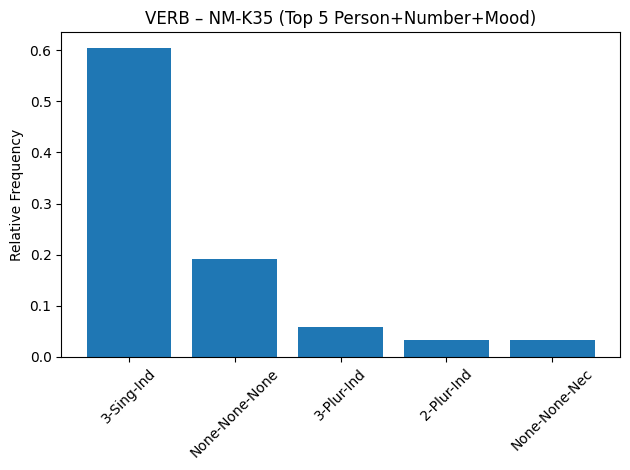

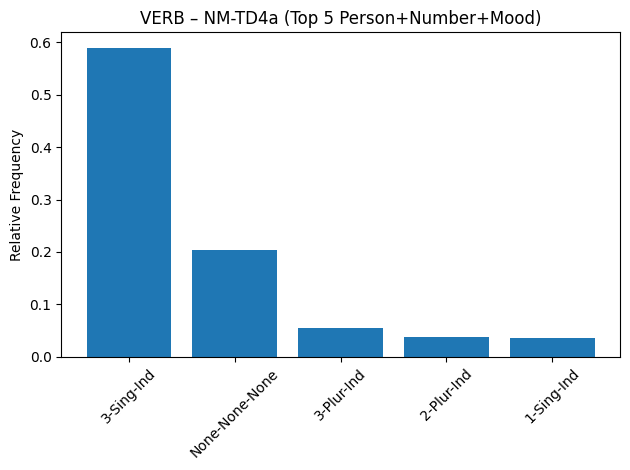

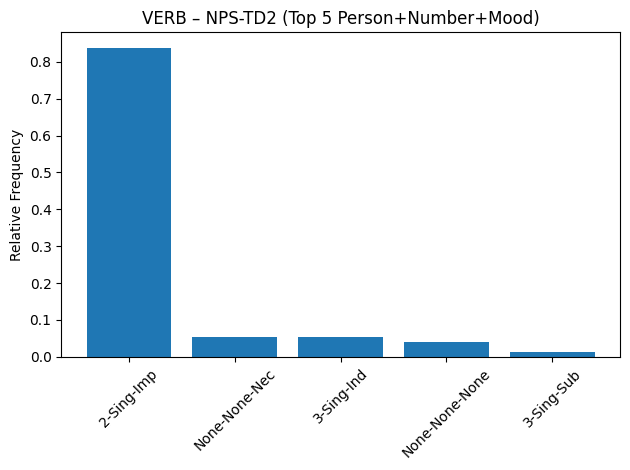

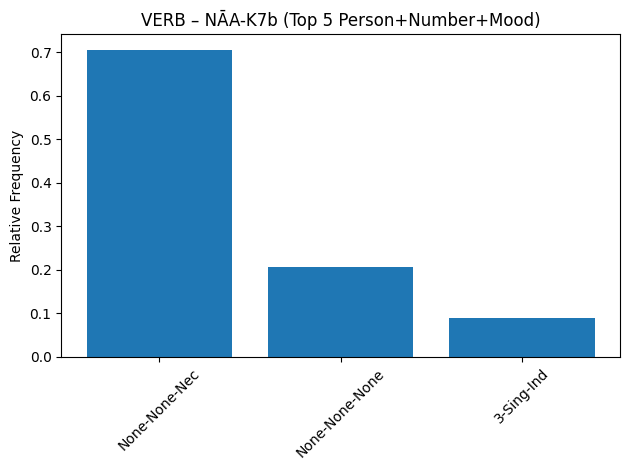

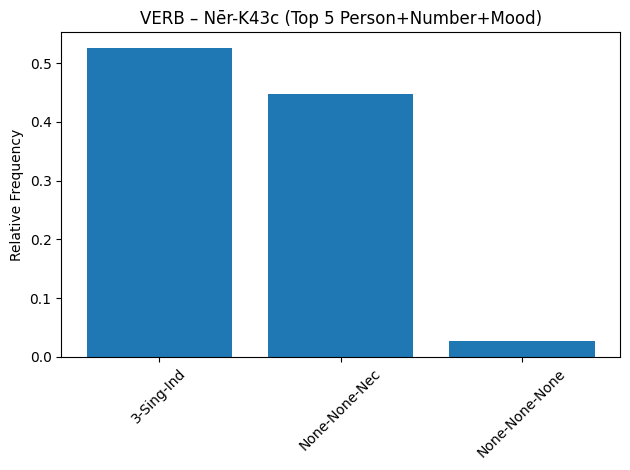

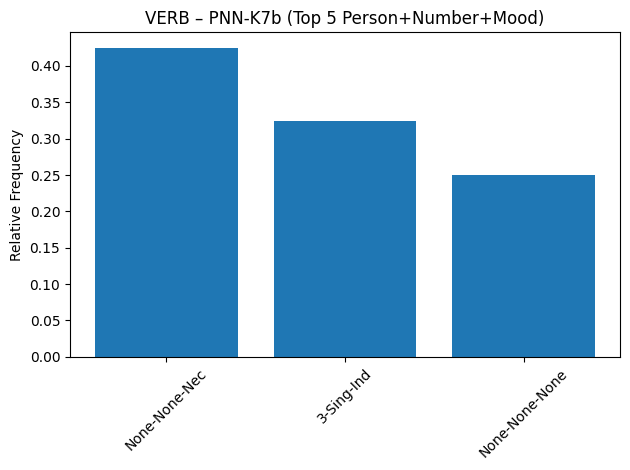

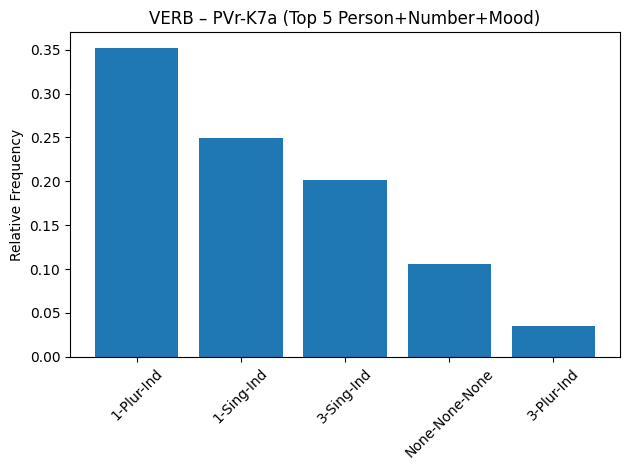

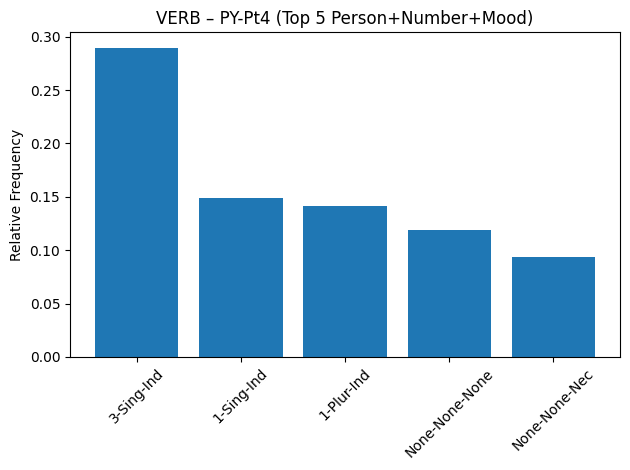

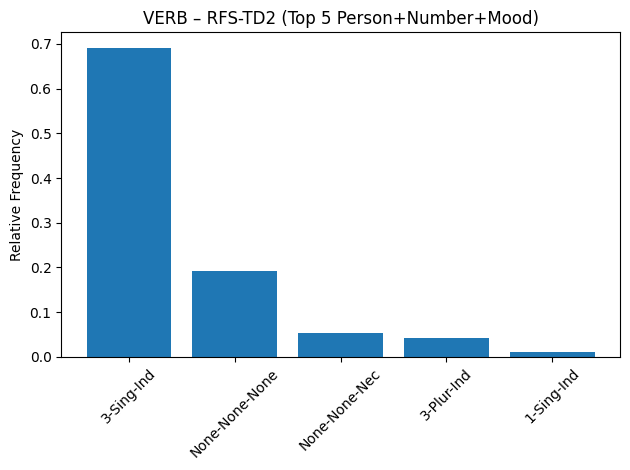

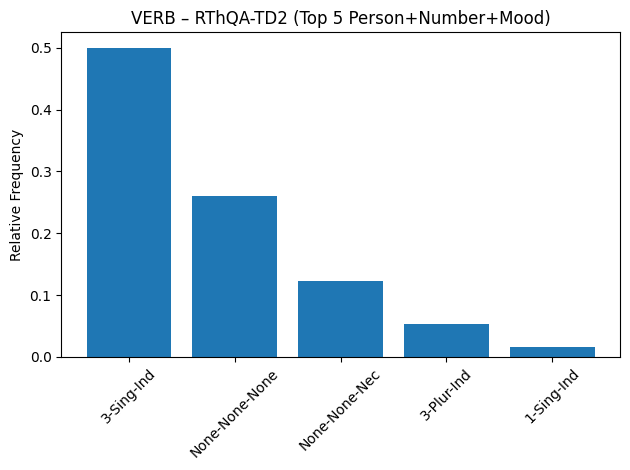

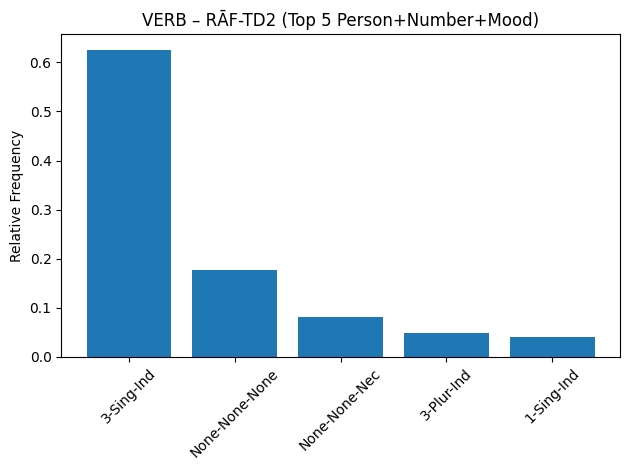

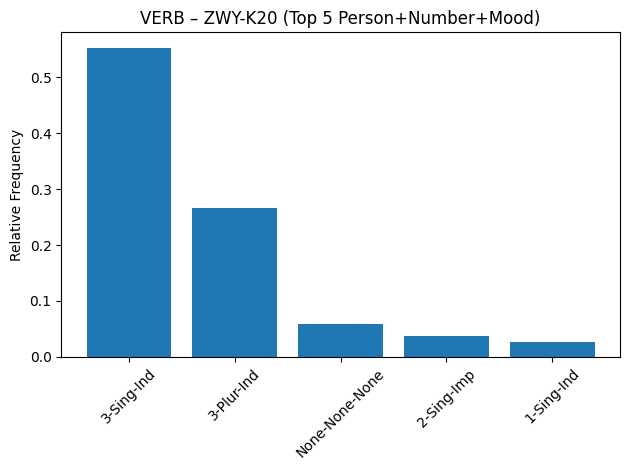

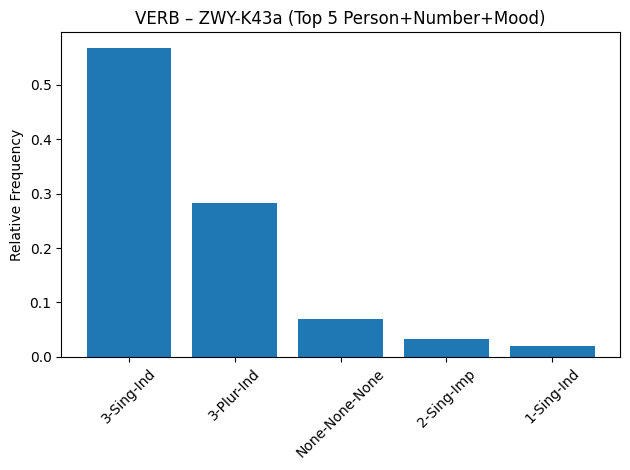

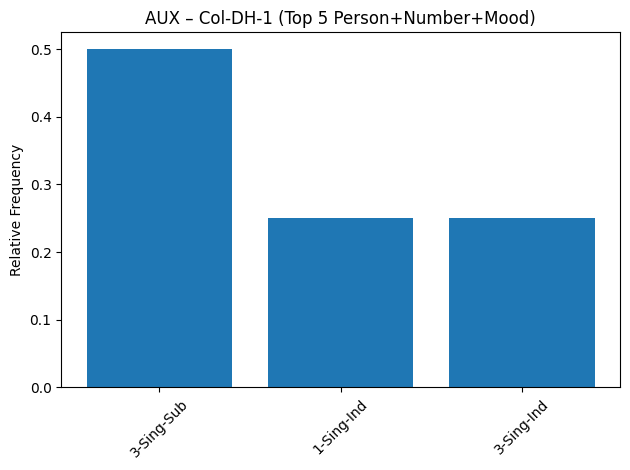

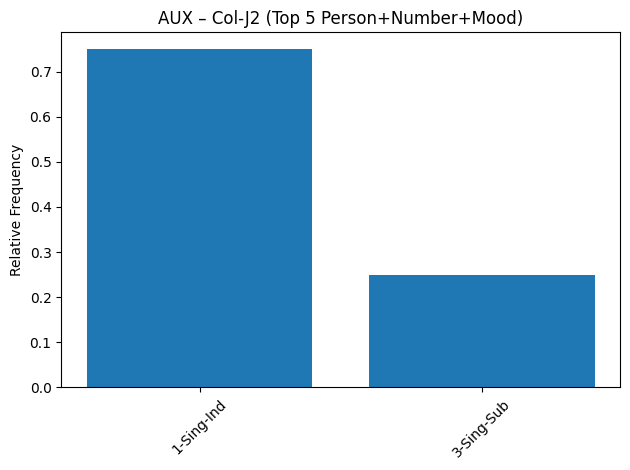

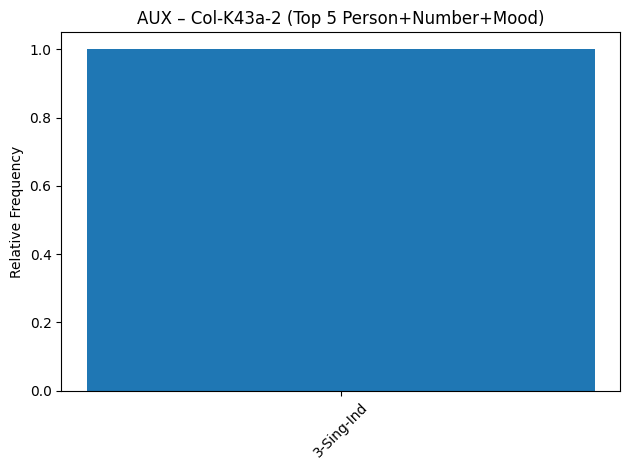

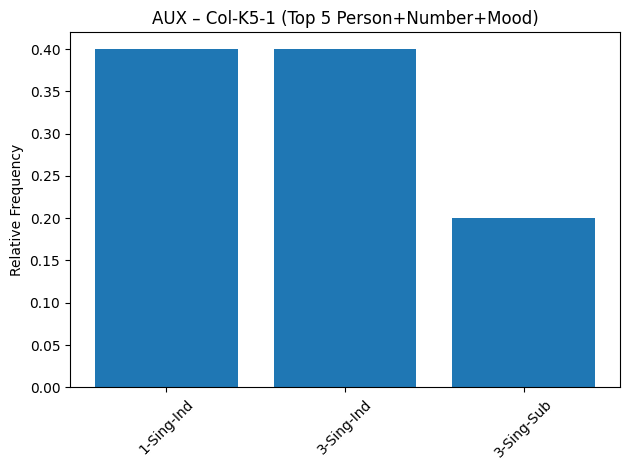

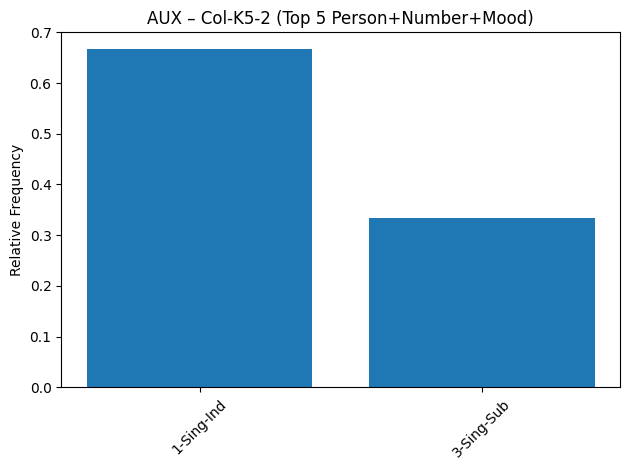

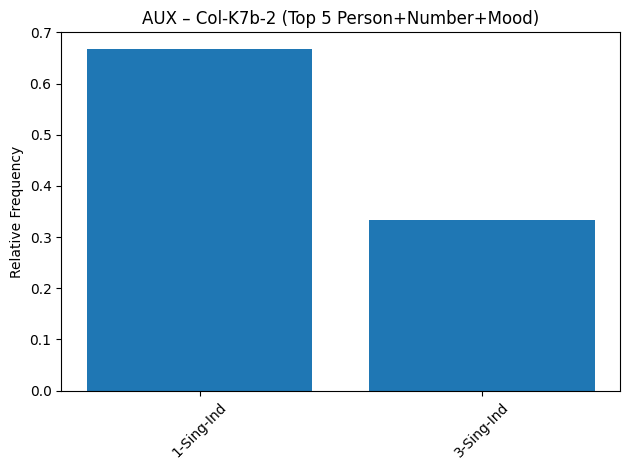

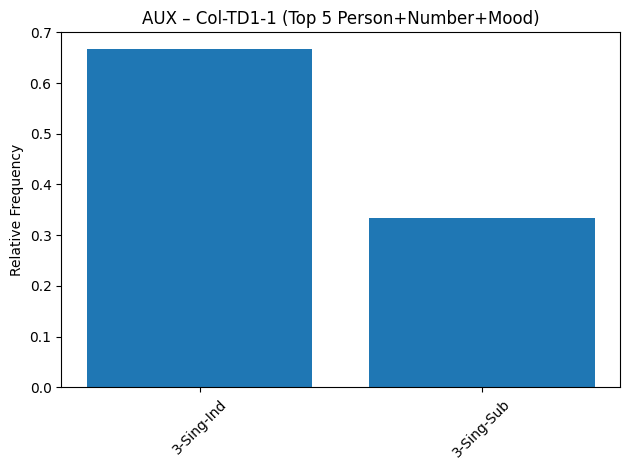

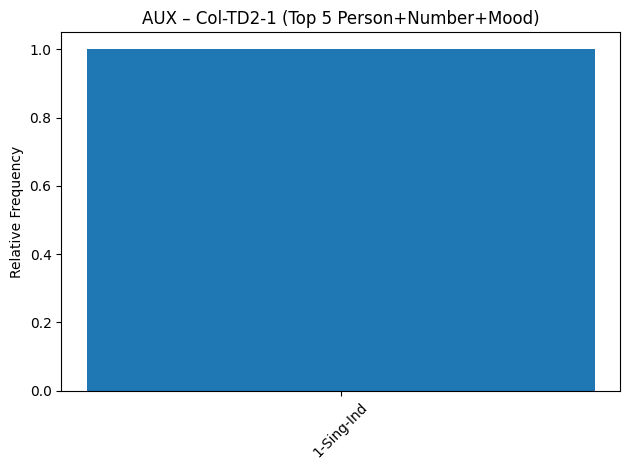

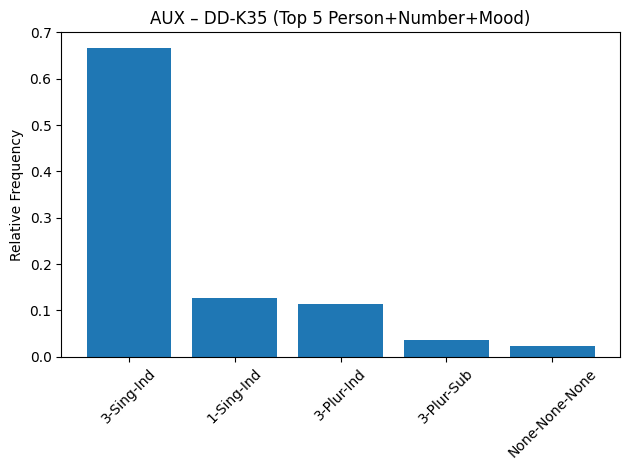

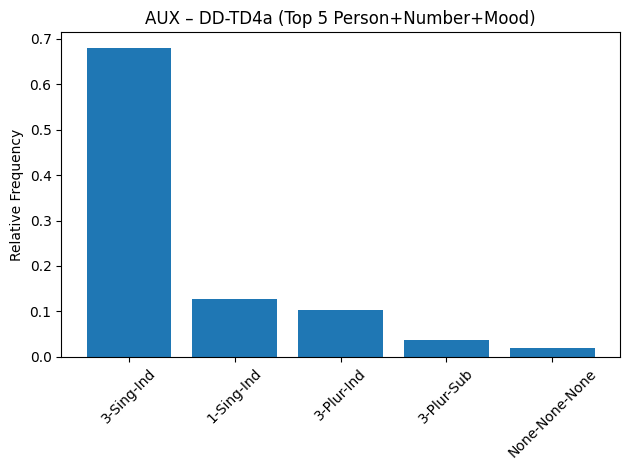

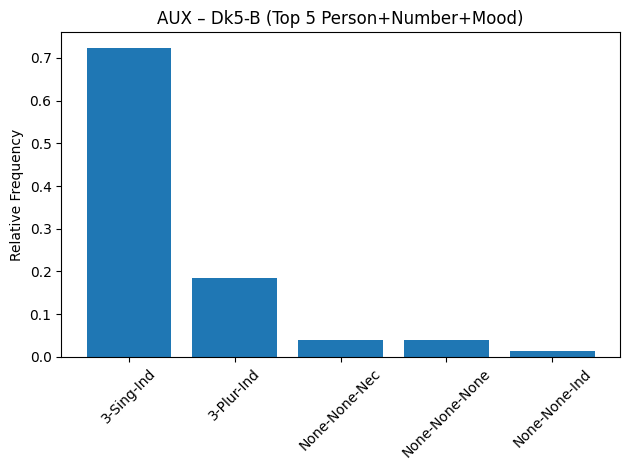

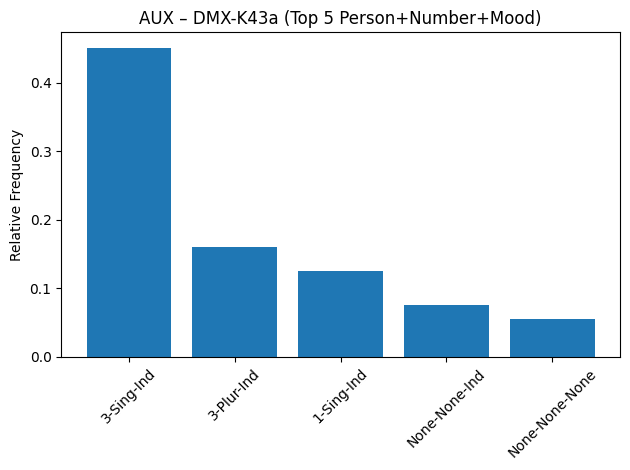

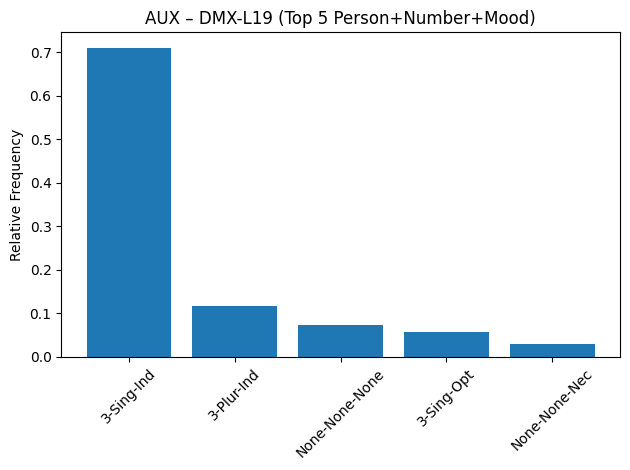

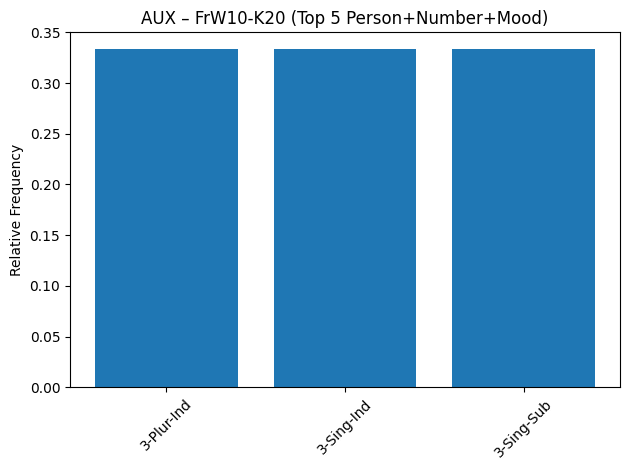

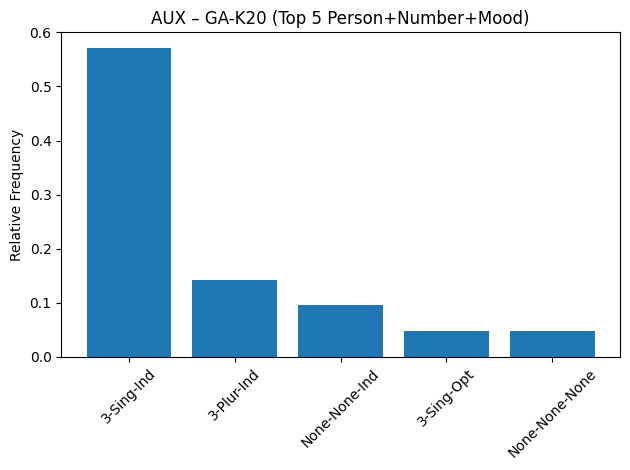

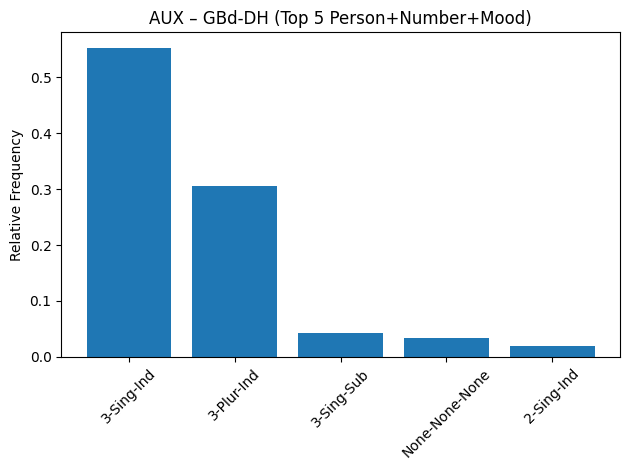

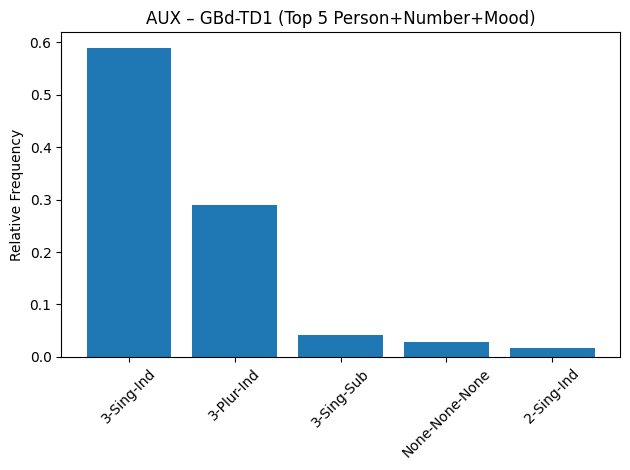

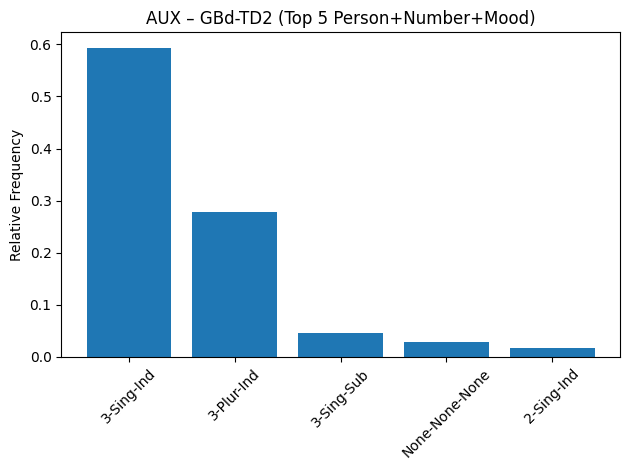

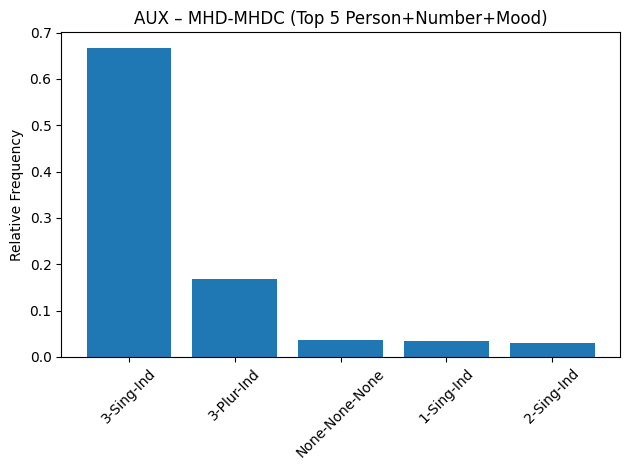

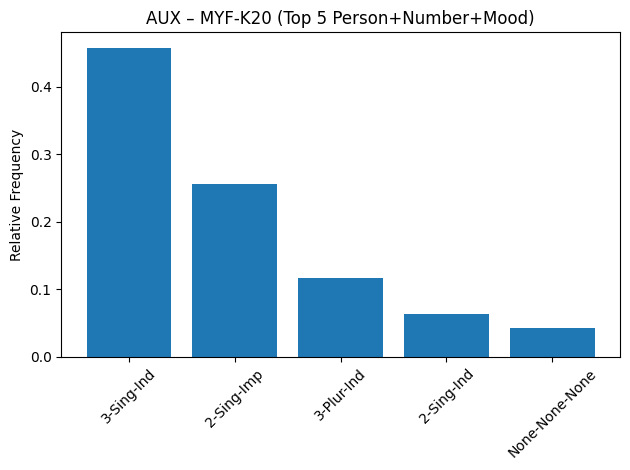

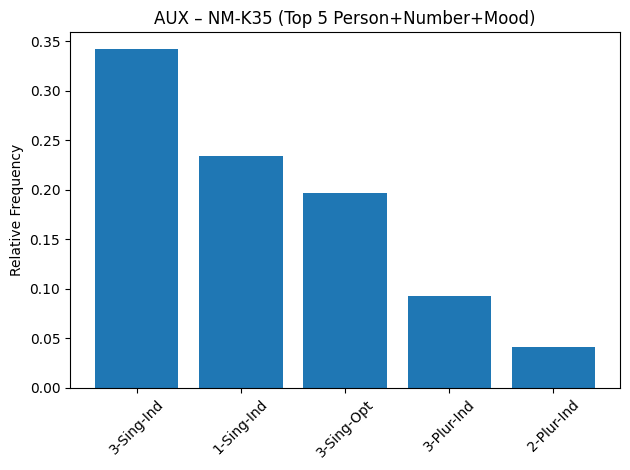

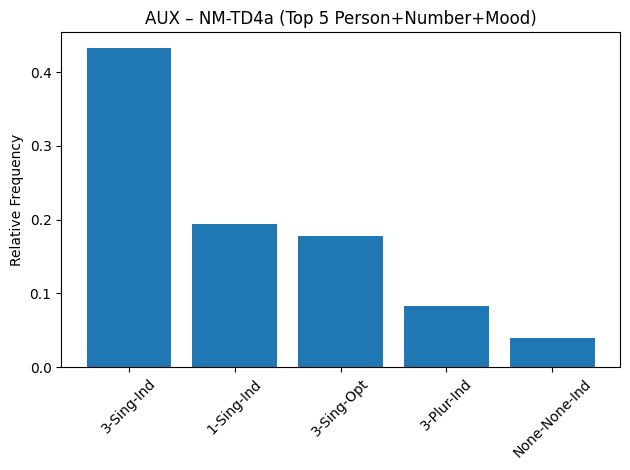

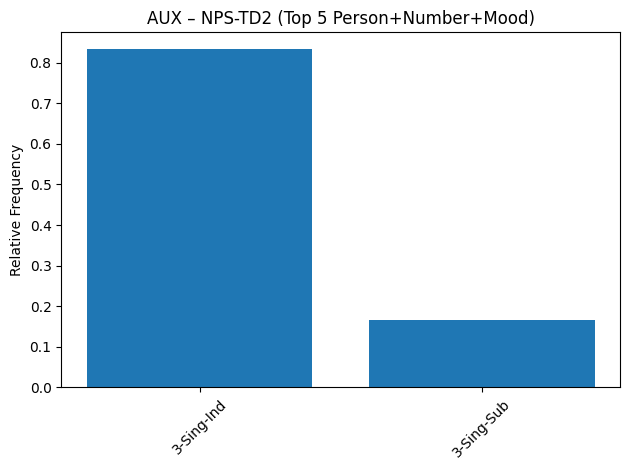

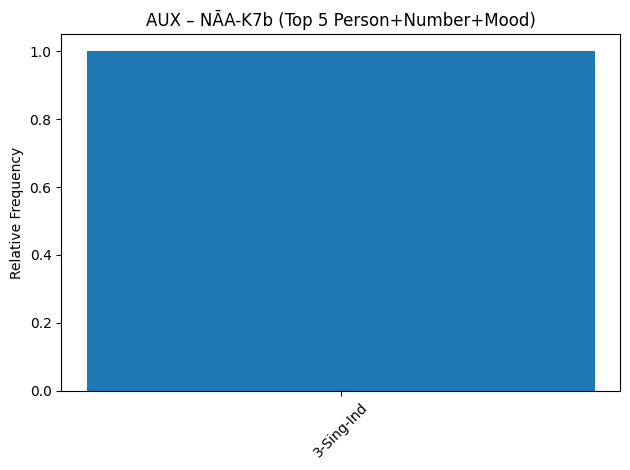

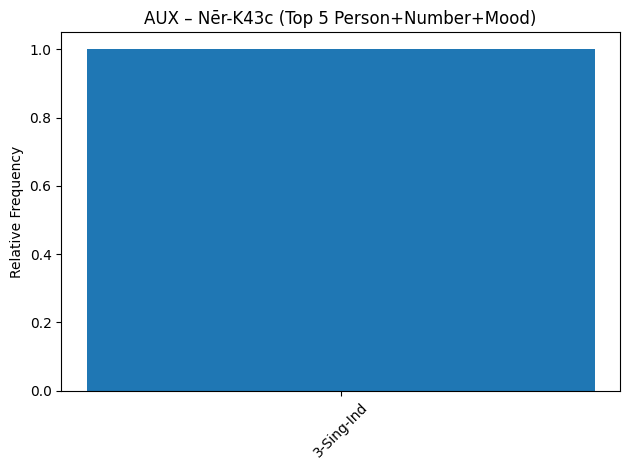

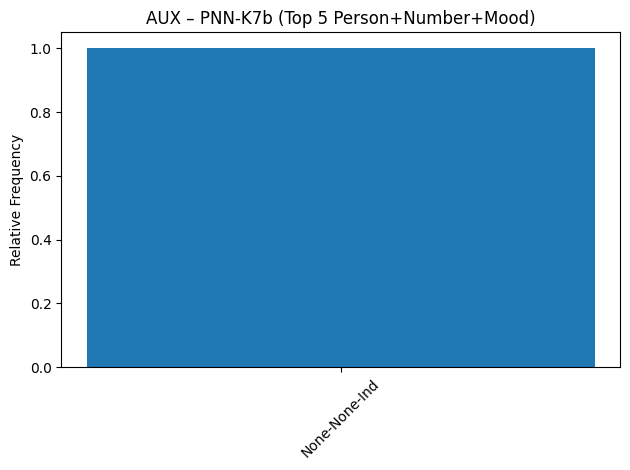

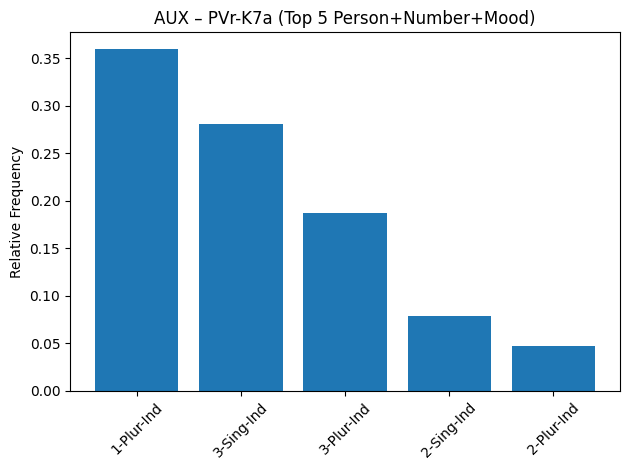

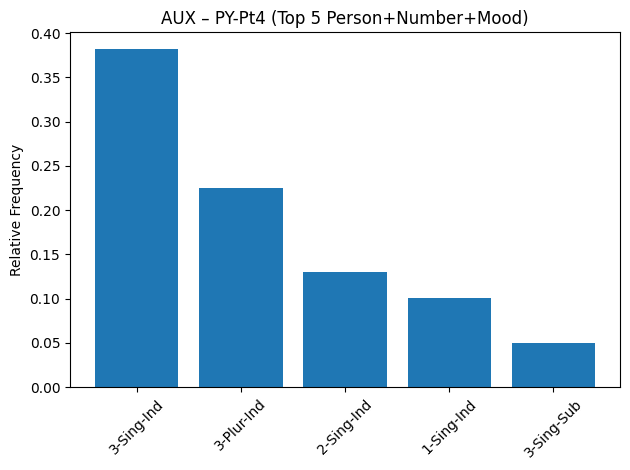

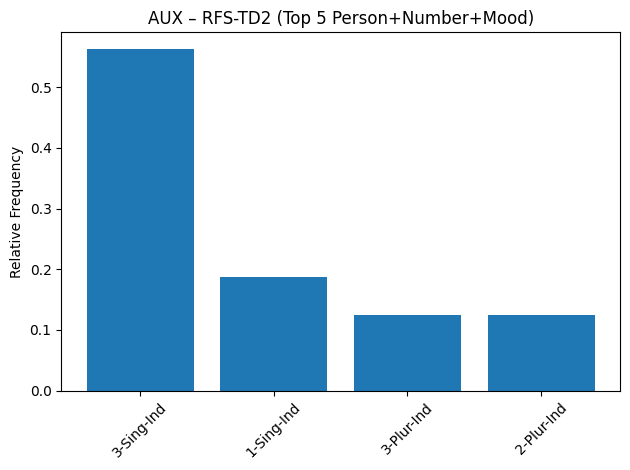

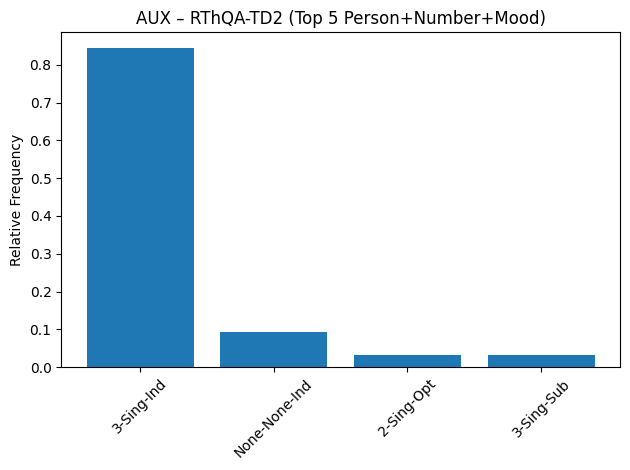

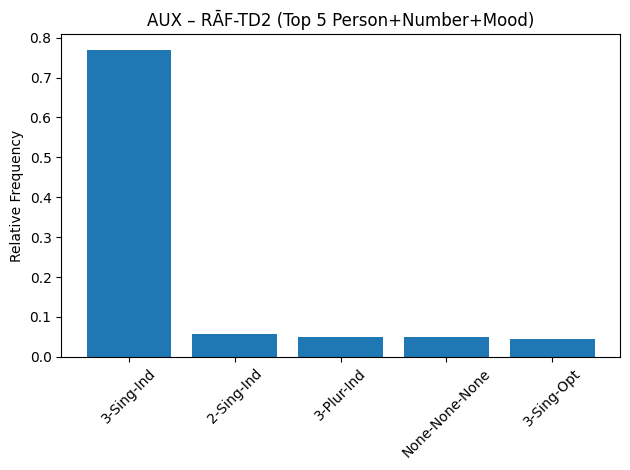

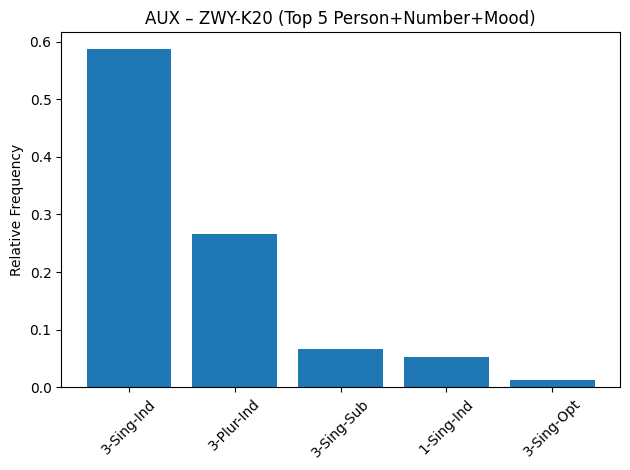

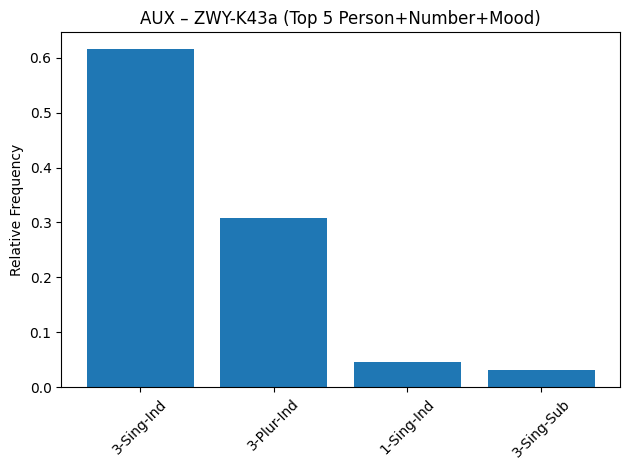

In [49]:
plot_combined_per_text(combo_per_text, "VERB")
plot_combined_per_text(combo_per_text, "AUX")

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_combined_per_text(per_text, pos="VERB", top_n=10):
    
    rows = []

    for file, counter in per_text[pos].items():
        total = sum(counter.values())
        
        if total == 0:
            continue
        
        for combo, count in counter.items():
            rows.append((file, combo, count / total))

    if not rows:
        return

    df = pd.DataFrame(rows, columns=["file", "combo", "ratio"])

    # pivot to wide format
    pivot = df.pivot(index="file", columns="combo", values="ratio").fillna(0)

    # keep only most frequent combos overall
    top_combos = pivot.mean().sort_values(ascending=False).head(top_n).index
    pivot = pivot[top_combos]

    # plot
    pivot.plot(kind="bar", stacked=True, figsize=(14, 6))

    plt.title(f"Person–Number–Mood combinations per text ({pos})")
    plt.ylabel("Relative frequency")
    plt.xlabel("Text")
    plt.xticks(rotation=90)
    plt.legend(title="Combo", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

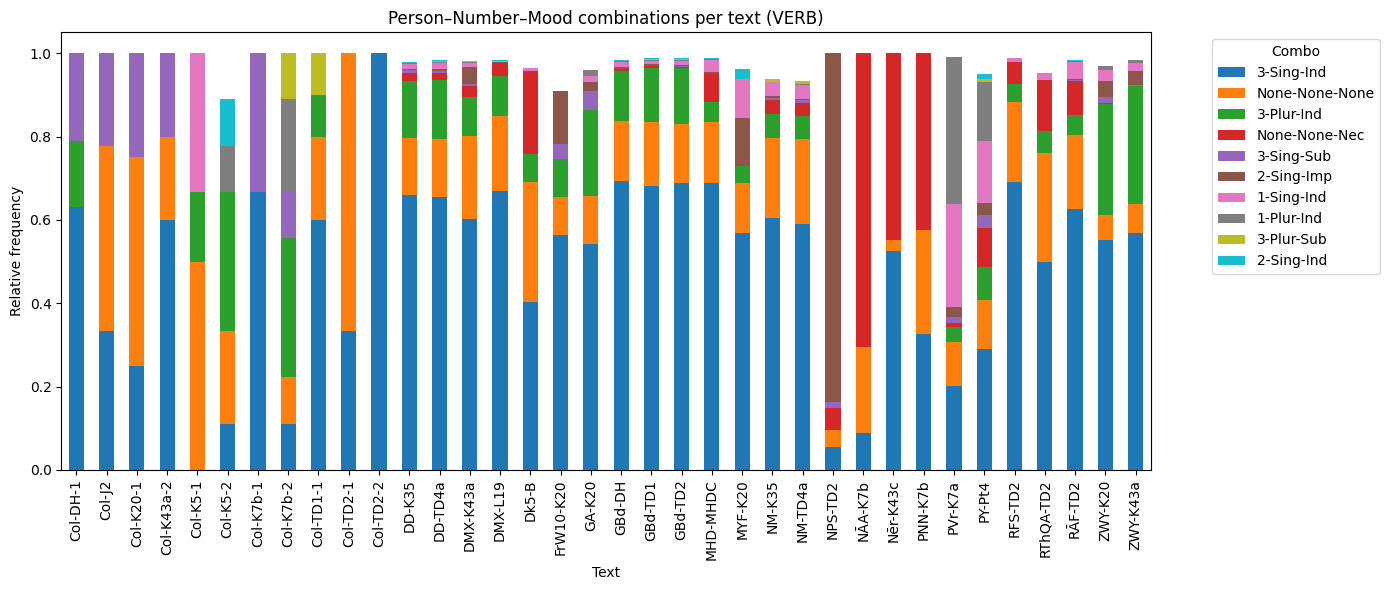

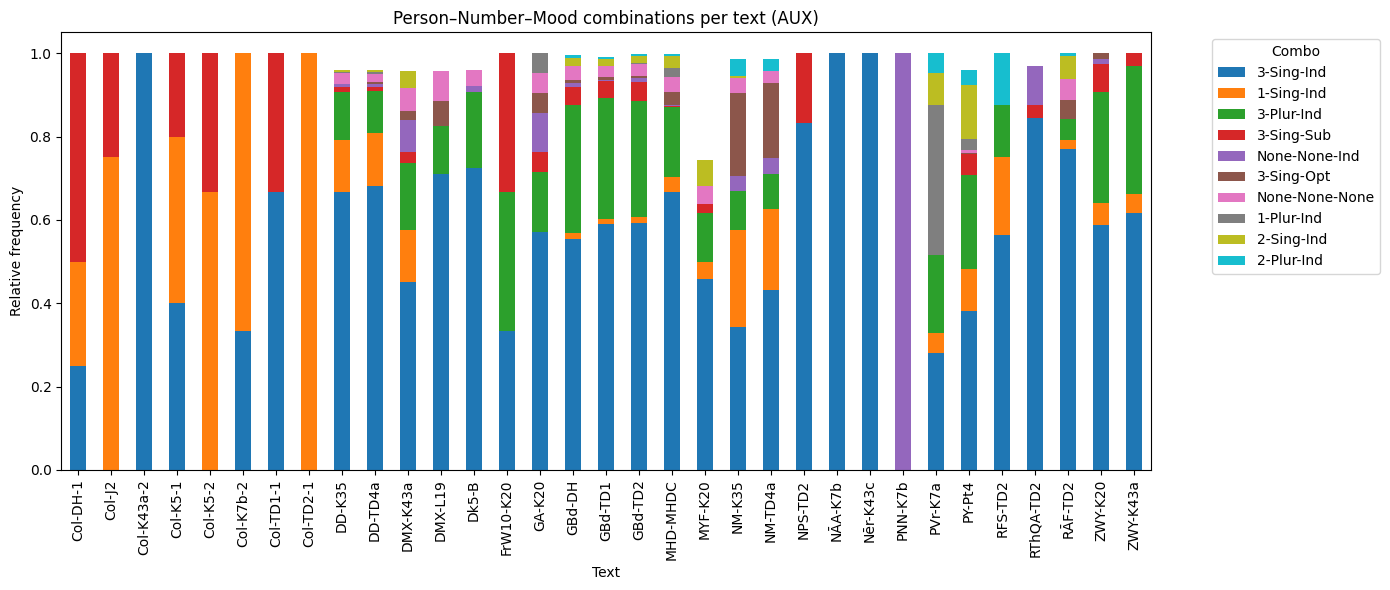

In [56]:
combo_per_text = combined_person_number_mood_per_text(annotated_corpus)

plot_combined_per_text(combo_per_text, "VERB")
plot_combined_per_text(combo_per_text, "AUX")

In [63]:
from collections import defaultdict, Counter
import pandas as pd

# =========================================================
# 1. FEATURE EXTRACTION
# =========================================================

def get_person_number_mood(feats):
    if not feats:
        return ("None", "None", "None")

    return (
        feats.get("Person", "None"),
        feats.get("Number", "None"),
        feats.get("Mood", "None")
    )

# =========================================================
# 2. SAFE STRUCTURE BUILDER (FIXED)
# =========================================================

def build_pnm_per_text(corpus, pos_list=("VERB", "AUX")):

    # IMPORTANT: explicit initialization (no lambda nesting bugs)
    per_text = {pos: {} for pos in pos_list}

    for sent in corpus:
        text = sent.file_name

        for tok in sent.get_tokens():
            pos = tok.upos

            if pos not in pos_list:
                continue

            feats = tok.feats
            combo = get_person_number_mood(feats)

            # ---- initialize safely ----
            if text not in per_text[pos]:
                per_text[pos][text] = Counter()

            # ---- safe increment ----
            per_text[pos][text][combo] += 1

    return per_text

# =========================================================
# 3. TABLE CREATION
# =========================================================

def pnm_per_text_to_table(per_text, pos="VERB"):

    rows = []

    for text, counter in per_text[pos].items():
        total = sum(counter.values())

        for combo, count in counter.items():

            rows.append({
                "Text": text,
                "Combination": "-".join(combo),
                "Count": count,
                "Ratio": count / total if total > 0 else 0
            })

    df = pd.DataFrame(rows)

    return df.sort_values(["Text", "Count"], ascending=[True, False])

# =========================================================
# 4. RUN
# =========================================================

combo_per_text = build_pnm_per_text(annotated_corpus)

df_verb = pnm_per_text_to_table(combo_per_text, "VERB")
df_aux  = pnm_per_text_to_table(combo_per_text, "AUX")

# =========================================================
# 5. OUTPUT
# =========================================================

display(df_verb)
display(df_aux)

,Text,Combination,Count,Ratio
0,Col-DH-1,3-Sing-Ind,12,0.631579
1,Col-DH-1,3-Sing-Sub,4,0.210526
2,Col-DH-1,3-Plur-Ind,3,0.157895
3,Col-J2,None-None-None,4,0.444444
4,Col-J2,3-Sing-Ind,3,0.333333
...,...,...,...,...
358,ZWY-K43a,3-Plur-Imp,1,0.002160
359,ZWY-K43a,3-None-Sub,1,0.002160
360,ZWY-K43a,None-None-Nec,1,0.002160
361,ZWY-K43a,2-Sing-Sub,1,0.002160


,Text,Combination,Count,Ratio
0,Col-DH-1,3-Sing-Sub,2,0.500000
1,Col-DH-1,1-Sing-Ind,1,0.250000
2,Col-DH-1,3-Sing-Ind,1,0.250000
4,Col-J2,1-Sing-Ind,3,0.750000
3,Col-J2,3-Sing-Sub,1,0.250000
...,...,...,...,...
189,ZWY-K20,None-None-Ind,1,0.013333
190,ZWY-K43a,3-Sing-Ind,40,0.615385
192,ZWY-K43a,3-Plur-Ind,20,0.307692
191,ZWY-K43a,1-Sing-Ind,3,0.046154


In [64]:
# =========================================================
# SAVE OUTPUT TABLES
# =========================================================

output_path_verb = "pnm_verb_per_text.csv"
output_path_aux  = "pnm_aux_per_text.csv"

df_verb.to_csv(output_path_verb, index=False, encoding="utf-8")
df_aux.to_csv(output_path_aux, index=False, encoding="utf-8")

print("Saved:")
print(output_path_verb)
print(output_path_aux)

Saved:
pnm_verb_per_text.csv
pnm_aux_per_text.csv


In [65]:
def make_wide_table(df):
    return df.pivot_table(
        index="Text",
        columns="Combination",
        values="Ratio",
        fill_value=0
    ).reset_index()

wide_verb = make_wide_table(df_verb)
wide_aux = make_wide_table(df_aux)

wide_verb.to_csv("pnm_verb_wide.csv", index=False, encoding="utf-8")
wide_aux.to_csv("pnm_aux_wide.csv", index=False, encoding="utf-8")

print("Saved wide-format CSVs.")

Saved wide-format CSVs.
